# Práctica B4-T2 — XAI: construcción, optimización y auditoría de un modelo de concesión de crédito

**Máster MIAX — Módulo B4, Tema 2 (Explicabilidad / XAI)**

**Componentes del grupo:** 
- Josep Perez Segura
- Natalia San Jose Ortega
- Emilio Sanchez Martinez

**Entregables:** este notebook + `cs_produccion1.csv` (escenario 1: FP=FN=1) + `cs_produccion2.csv` (escenario 2: FP=1, FN=10).

## Resumen ejecutivo de resultados

| Escenario | Matriz de coste | Modelo final | Umbral (producción) | **Coste medio estimado** | Estrategia trivial |
|---|---|---|---|---|---|
| 1 | FP=1, FN=1 | LightGBM (300 árboles, 15 hojas) | 0,523 | **0,0635** | 0,0668 (conceder a todos) |
| 2 | FP=1, FN=10 | el mismo modelo, otro umbral | 0,092 | **0,3351** | 0,6684 (conceder a todos) |

El coste estimado procede de un conjunto de test interno de 20.934 solicitudes jamás usadas para
entrenar ni para elegir el umbral; al no existir drift entre construcción y producción (§2.7), es
la mejor estimación disponible del coste que obtendremos en producción. El detalle de cada cifra:
secciones 4, 5 y 11; la tabla final con todas las variantes exploradas, en la sección 12.

El resultado central del proyecto es que ambos escenarios se
resuelven con el *mismo* clasificador probabilístico: cambiar la matriz de coste no exige
reentrenar, solo mover el umbral de decisión (de 0,52 a 0,09), que multiplica por 9 la tasa de
denegación (del 2% al 18%). La auditoría (secciones 7-9) muestra el precio menos visible de esa
palanca: más falsos positivos, concentrados en los clientes jóvenes.

## 1. Introducción y objetivo

Se nos pide **construir, optimizar y auditar** un modelo de concesión de crédito sobre el dataset
*Give Me Some Credit*, y generar predicciones para un fichero de producción de 45.000 solicitudes
bajo dos matrices de coste distintas. La nota se reparte al 50% entre el **coste promedio en
producción** y la **calidad del análisis y la auditoría**, así que este notebook dedica tanto
esfuerzo a explicar y criticar el modelo como a optimizarlo.

### Convención de costes (fijada explícitamente para evitar ambigüedades)

La clase positiva es `SeriousDlqin2yrs = 1`: el cliente presentó un impago grave (90+ días) en los
2 años siguientes. La decisión de negocio asociada a predecir 1 es **denegar** el crédito.

| | Real 0 (buen pagador) | Real 1 (moroso) |
|---|---|---|
| **Predicción 0** (conceder) | acierto, coste 0 | **Falso Negativo**: concedemos a un moroso → coste C_FN |
| **Predicción 1** (denegar) | **Falso Positivo**: denegamos a un buen pagador → coste C_FP | acierto, coste 0 |

- **Escenario 1**: C_FP = C_FN = 1 (equivale a minimizar la tasa de error).
- **Escenario 2**: C_FP = 1, C_FN = 10 (conceder a un moroso es 10 veces más grave que
  perder un buen cliente, la asimetría habitual en banca: el impago cuesta el principal,
  denegar bien solo el margen).

### Umbral de decisión óptimo (teoría)

Para probabilidades bien calibradas, el coste esperado se minimiza denegando cuando
p(moroso) > t* con:

$$t^* = \frac{C_{FP}}{C_{FP} + C_{FN}}$$

es decir, **t\* = 0,5** en el escenario 1 y **t\* = 1/11 ≈ 0,091** en el escenario 2. En las
secciones 4 y 5 contrastaremos este umbral teórico con el óptimo empírico (si difieren, el
modelo está mal calibrado) y compararemos además con una estrategia cost-sensitive en el
propio entrenamiento (`scale_pos_weight`).

### Enfoque

Modelo principal: *LightGBM** (gradient boosting; maneja valores ausentes de forma nativa, lo
que permite un pipeline honesto sin imputaciones agresivas). Baseline interpretable: **regresión
logística regularizada**. La elección se justifica con resultados en la sección 4, y la sección 10
discute por qué se descarta el enfoque de *multi-armed bandit* que menciona el enunciado.
Auditoría (secciones 7-9): modelo subrogado con reglas, contrafactuales con respuesta redactada
al cliente y un bloque de explicabilidad complementaria. En la sección 9 usamos SHAP como eje
principal, pero lo contrastamos con Permutation Feature Importance orientada a coste, PDP/ICE/ALE
para efectos marginales, LIME para explicaciones locales alternativas, análisis de equidad por edad
y estabilidad de las explicaciones entre escenarios.

In [108]:
# Si falta algún paquete (entorno limpio / Colab), descomentar y ejecutar:
# %pip install -r requirements.txt

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
# Generador moderno de NumPy. Regla del proyecto: nada de np.random.* legacy (estado global);
# cada sección que necesite aleatoriedad crea su propio default_rng(SEED) para que las celdas
# sean re-ejecutables en cualquier orden sin alterar resultados.
rng = np.random.default_rng(SEED)

pd.options.display.max_columns = None
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

## 2. Carga y exploración de datos

Antes de modelar hacemos inventario: esquema, nulos, desbalanceo, duplicados, valores
imposibles y posibles fugas de información. Cada hallazgo de esta sección se traduce en una
decisión concreta de preprocesamiento en la sección 3.

In [110]:
df_con = pd.read_csv("cs_construccion.csv")
df_pro = pd.read_csv("cs_produccion.csv")
dicc = pd.read_csv("DataDictionary.csv", sep=";").drop(columns="Unnamed: 0").set_index("Variable Name")

TARGET = "SeriousDlqin2yrs"

print(f"Construcción: {df_con.shape[0]:,} filas x {df_con.shape[1]} columnas")
print(f"Producción:   {df_pro.shape[0]:,} filas x {df_pro.shape[1]} columnas")
print(f"Mismas columnas y mismo orden: {list(df_con.columns) == list(df_pro.columns)}")
print(f"Target vacío en producción: {df_pro[TARGET].isna().mean():.0%} (es lo que hay que predecir)")

pd.options.display.max_colwidth = None
dicc

Construcción: 105,000 filas x 11 columnas
Producción:   45,000 filas x 11 columnas
Mismas columnas y mismo orden: True
Target vacío en producción: 100% (es lo que hay que predecir)


,Description,Type
Variable Name,,
SeriousDlqin2yrs,Person experienced 90 days past due delinquency or worse,Y/N
RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,percentage
age,Age of borrower in years,integer
NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,integer
DebtRatio,"Monthly debt payments, alimony,living costs divided by monthy gross income",percentage
MonthlyIncome,Monthly income,real
NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),integer
NumberOfTimes90DaysLate,Number of times borrower has been 90 days or more past due.,integer
NumberRealEstateLoansOrLines,Number of mortgage and real estate loans including home equity lines of credit,integer


**Nota importante sobre producción**: el fichero no tiene columna de identificador de cliente,
de modo que **el identificador implícito es la posición de la fila**. Ninguna etapa del pipeline
puede eliminar, imputar-por-descarte ni reordenar filas de producción: hay que emitir una
predicción para las 45.000. Esto condiciona el preprocesamiento, no se pueden eliminar los valores nulos ni outliers.

In [111]:
resumen = pd.DataFrame({
    "tipo": df_con.dtypes.astype(str),
    "n_nulos": df_con.isna().sum(),
    "%_nulos": (100 * df_con.isna().mean()).round(2),
    "n_unicos": df_con.nunique(),
    "min": df_con.min(),
    "mediana": df_con.median(),
    "max": df_con.max(),
})
resumen

,tipo,n_nulos,%_nulos,n_unicos,min,mediana,max
SeriousDlqin2yrs,int64,0,0.00,2,0.0,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,float64,0,0.00,88641,0.0,0.154674,22198.0
age,int64,0,0.00,86,0.0,52.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.00,14,0.0,0.000000,98.0
DebtRatio,float64,0,0.00,82384,0.0,0.366143,329664.0
MonthlyIncome,float64,20795,19.80,12062,0.0,5400.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,int64,0,0.00,57,0.0,8.000000,58.0
NumberOfTimes90DaysLate,int64,0,0.00,17,0.0,0.000000,98.0
NumberRealEstateLoansOrLines,int64,0,0.00,27,0.0,1.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,int64,0,0.00,11,0.0,0.000000,98.0


Todas las variables son numéricas (no hay que codificar categóricas). Se ven ya tres
problemas: nulos en `MonthlyIncome` (19,8%) y `NumberOfDependents` (2,6%), una edad mínima
de 0 años, y máximos sospechosos de 98 en las tres variables de historial de impagos. Los
analizamos uno a uno.

### 2.1 Desbalanceo del target y coste de las estrategias triviales

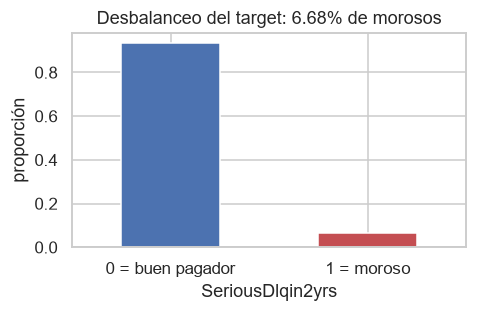

Coste medio de las estrategias triviales (la referencia mínima a batir):
  Escenario 1 (FP=1, FN=1)  — conceder a todos: 0.0668 | denegar a todos: 0.9332
  Escenario 2 (FP=1, FN=10) — conceder a todos: 0.6684 | denegar a todos: 0.9332


In [112]:
tasa_mora = df_con[TARGET].mean()

fig, ax = plt.subplots(figsize=(4.5, 3))
df_con[TARGET].value_counts(normalize=True).plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["0 = buen pagador", "1 = moroso"], rotation=0)
ax.set_ylabel("proporción")
ax.set_title(f"Desbalanceo del target: {tasa_mora:.2%} de morosos")
plt.tight_layout()
plt.show()

print("Coste medio de las estrategias triviales (la referencia mínima a batir):")
print(f"  Escenario 1 (FP=1, FN=1)  — conceder a todos: {tasa_mora:.4f} | denegar a todos: {1 - tasa_mora:.4f}")
print(f"  Escenario 2 (FP=1, FN=10) — conceder a todos: {10 * tasa_mora:.4f} | denegar a todos: {1 - tasa_mora:.4f}")

Solo un 6,7% de morosos: cualquier métrica basada en accuracy será engañosa (un modelo
que concede todo "acierta" el 93%). En el escenario 1 la estrategia trivial *conceder a todos*
ya logra coste 0,067; nuestro modelo tiene que bajar de ahí. En el escenario 2 las dos
estrategias triviales son caras (0,668 y 0,933): la matriz asimétrica obliga al modelo a
detectar morosos de verdad, no le basta con ser conservador.

### 2.2 Distribuciones

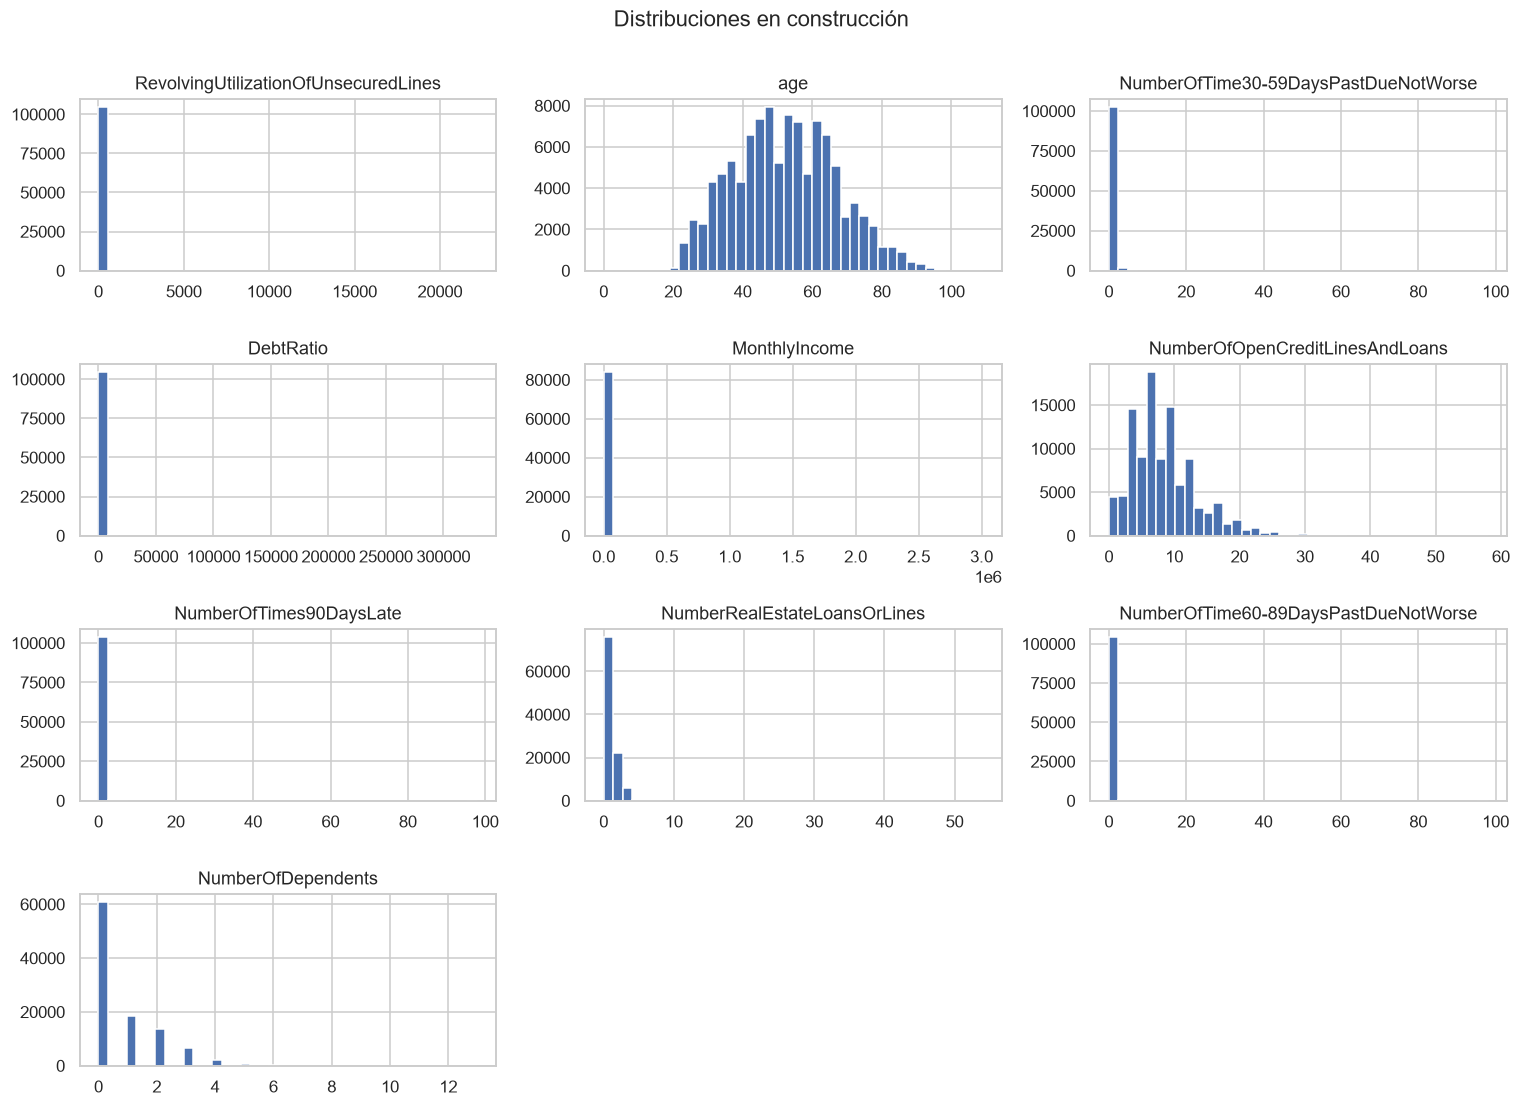

In [113]:
df_con.drop(columns=TARGET).hist(figsize=(14, 10), bins=40)
plt.suptitle("Distribuciones en construcción", y=1.005)
plt.tight_layout()
plt.show()

Colas larguísimas en las variables monetarias (`MonthlyIncome`, `DebtRatio`,
`RevolvingUtilizationOfUnsecuredLines`) y una masa aislada cerca de 96-98 en las tres
variables de impagos. Ese aislamiento no es una cola: son **códigos especiales**.

### 2.3 Los códigos 96/98 en las variables de morosidad

In [114]:
VARS_MORA = ["NumberOfTime30-59DaysPastDueNotWorse",
             "NumberOfTime60-89DaysPastDueNotWorse",
             "NumberOfTimes90DaysLate"]

for c in VARS_MORA:
    print(f"{c} — valores más altos:")
    print(df_con[c].value_counts().sort_index().tail(4).to_string(), "\n")

mask_cent = (df_con[VARS_MORA] >= 96).any(axis=1)
en_las_tres = (df_con[VARS_MORA] >= 96).all(axis=1)
print(f"Filas con algún 96/98: {mask_cent.sum()} | con 96/98 en las TRES variables a la vez: {en_las_tres.sum()}")
print(f"Tasa de mora en esas filas: {df_con.loc[mask_cent, TARGET].mean():.1%} (global: {tasa_mora:.1%})")
print(f"En producción hay {(df_pro[VARS_MORA] >= 96).any(axis=1).sum()} filas con estos códigos (también hay que predecirlas)")

NumberOfTime30-59DaysPastDueNotWorse — valores más altos:
NumberOfTime30-59DaysPastDueNotWorse
10      3
12      2
96      3
98    185 

NumberOfTime60-89DaysPastDueNotWorse — valores más altos:
NumberOfTime60-89DaysPastDueNotWorse
7       7
8       2
96      3
98    185 

NumberOfTimes90DaysLate — valores más altos:
NumberOfTimes90DaysLate
14      2
15      2
96      3
98    185 

Filas con algún 96/98: 188 | con 96/98 en las TRES variables a la vez: 188
Tasa de mora en esas filas: 54.3% (global: 6.7%)
En producción hay 81 filas con estos códigos (también hay que predecirlas)


Los valores 96 y 98 no son recuentos reales: el máximo verosímil observado es 12/8/15, y
el 96/98 aparece **siempre en las tres variables a la vez**, es un código administrativo
(tipo "historial no evaluable" o "impago crónico"). Y es tremendamente informativo: esas filas
tienen un **54% de impago**, ocho veces la tasa base. El notebook de clase las elimina; nosotros
no podemos (hay 81 en producción) ni queremos (es señal valiosísima). Decisión para la sección
3: flag binario + valor capado, de modo que el modelo capture la señal sin tratar "98 impagos"
como una magnitud aritmética real, lo que además volvería absurdas las explicaciones
(contrafactuales del tipo "reduzca sus impagos de 98 a 97").

### 2.4 Nulos: ¿la ausencia de datos es informativa?

In [115]:
print(f"Mora con MonthlyIncome informado: {df_con.loc[df_con['MonthlyIncome'].notna(), TARGET].mean():.2%}")
print(f"Mora con MonthlyIncome ausente:   {df_con.loc[df_con['MonthlyIncome'].isna(), TARGET].mean():.2%}")
print()
print(f"Nulos MonthlyIncome      — construcción: {df_con['MonthlyIncome'].isna().mean():.1%} | producción: {df_pro['MonthlyIncome'].isna().mean():.1%}")
print(f"Nulos NumberOfDependents — construcción: {df_con['NumberOfDependents'].isna().mean():.1%}  | producción: {df_pro['NumberOfDependents'].isna().mean():.1%}")

Mora con MonthlyIncome informado: 6.98%
Mora con MonthlyIncome ausente:   5.49%

Nulos MonthlyIncome      — construcción: 19.8% | producción: 19.9%
Nulos NumberOfDependents — construcción: 2.6%  | producción: 2.6%


La ausencia de ingresos declarados **no es aleatoria**: quienes no informan ingresos tienen
una tasa de impago del 5,5% frente al 7,0% de quienes sí (quizá perfiles con otras fuentes de renta, o
solicitudes por canales distintos). Dos consecuencias: 
- Imputar sin más borraría esa señal, por lo que añadiremos un indicador de ausencia.
- Eliminar las filas con valores nulos no solo es inviable en producción (19,9% de nulos), sino que introduce un sesgo significativo en la muestra de entrenamiento.

### 2.5 Utilización de crédito: señal fuerte… y errores de unidad

In [116]:
bandas = pd.cut(df_con["RevolvingUtilizationOfUnsecuredLines"],
                bins=[-0.001, 0.5, 1, 10, np.inf],
                labels=["≤ 0,5", "(0,5 — 1]", "(1 — 10]", "> 10"])
tabla_util = df_con.groupby(bandas, observed=True)[TARGET].agg(n="size", tasa_mora="mean")
tabla_util["tasa_mora"] = (100 * tabla_util["tasa_mora"]).round(1)
tabla_util

,n,tasa_mora
RevolvingUtilizationOfUnsecuredLines,,
"≤ 0,5",75989,2.7
"(0,5 — 1]",26628,15.2
(1 — 10],2207,39.5
> 10,176,6.8


`RevolvingUtilizationOfUnsecuredLines` es un porcentaje de uso del crédito disponible, así
que debería vivir en [0, 1] (algo por encima si se rebasa el límite). El riesgo crece de forma
monótona hasta la banda (1, 10]: estar por encima del límite dispara la tasa de impago al 39,5%. Pero en
la banda >10 (176 casos, valores de hasta 50.708) la tasa de impago **vuelve a la tasa base (6,8%)**: si
fueran utilizaciones reales del 5.000%, serían los clientes más arriesgados del dataset. Casi
seguro son **errores de unidad** (saldos absolutos grabados donde iba un ratio). Los árboles
aíslan este rango sin contaminarse, pero para la regresión logística winsorizaremos; y en la
auditoría (sección 9) habrá que desconfiar de las explicaciones de estos 176 clientes: si la
variable de entrada es de mala calidad, la explicación también lo será.

### 2.6 Duplicados, edades imposibles y correlaciones

In [117]:
print(f"Duplicados exactos (las 11 columnas idénticas): {df_con.duplicated().sum()} filas sobrantes "
      f"({df_con.duplicated(keep=False).sum()} filas implicadas)")
print(f"Filas con age = 0: {(df_con['age'] == 0).sum()} en construcción, {(df_pro['age'] == 0).sum()} en producción")
print(f"Edad mínima real: {df_con.loc[df_con['age'] > 0, 'age'].min()} años (coherente: los menores no pueden solicitar crédito)")

Duplicados exactos (las 11 columnas idénticas): 331 filas sobrantes (547 filas implicadas)
Filas con age = 0: 1 en construcción, 0 en producción
Edad mínima real: 21 años (coherente: los menores no pueden solicitar crédito)


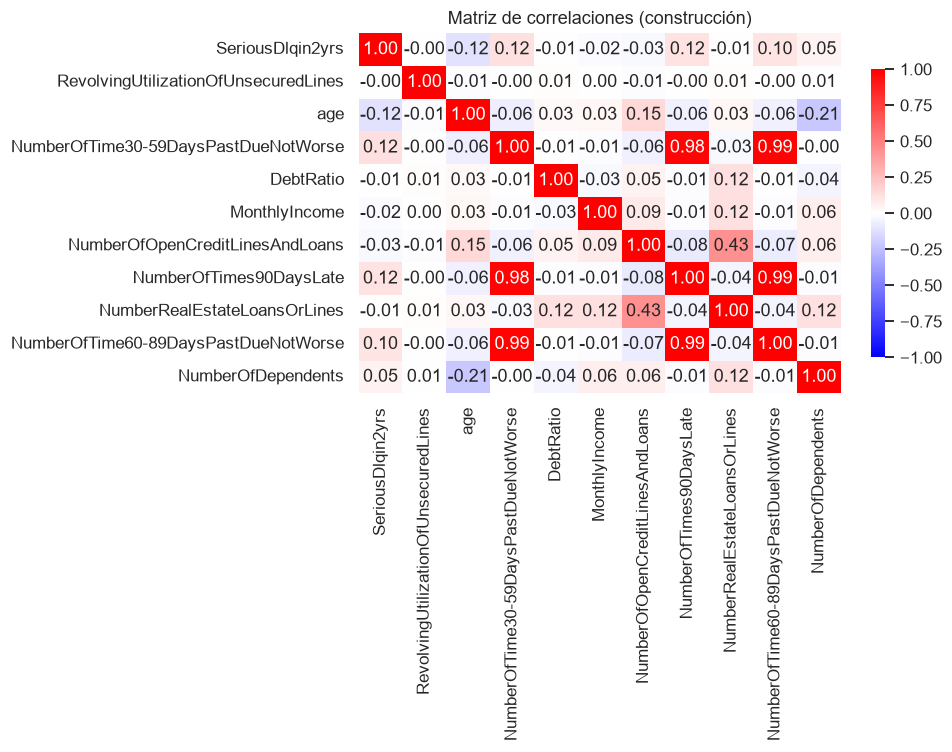

Correlación entre las tres variables de morosidad CON códigos 96/98:
                                      NumberOfTime30-59DaysPastDueNotWorse  NumberOfTime60-89DaysPastDueNotWorse  NumberOfTimes90DaysLate
NumberOfTime30-59DaysPastDueNotWorse                                  1.00                                  0.99                     0.98
NumberOfTime60-89DaysPastDueNotWorse                                  0.99                                  1.00                     0.99
NumberOfTimes90DaysLate                                               0.98                                  0.99                     1.00

Y SIN los códigos 96/98:
                                      NumberOfTime30-59DaysPastDueNotWorse  NumberOfTime60-89DaysPastDueNotWorse  NumberOfTimes90DaysLate
NumberOfTime30-59DaysPastDueNotWorse                                  1.00                                  0.30                     0.22
NumberOfTime60-89DaysPastDueNotWorse                                  0.30   

In [118]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_con.corr(), cmap="bwr", vmin=-1, vmax=1, annot=True, fmt=".2f",
            ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de correlaciones (construcción)")
plt.tight_layout()
plt.show()

print("Correlación entre las tres variables de morosidad CON códigos 96/98:")
print(df_con[VARS_MORA].corr().round(2).to_string())
print("\nY SIN los códigos 96/98:")
print(df_con.loc[~mask_cent, VARS_MORA].corr().round(2).to_string())

Las correlaciones de 0,98-0,99 entre las tres variables de impagos son un **artefacto de los
códigos 96/98** (aparecen en las tres a la vez): al quitarlos caen a 0,27-0,33. Otro motivo más
para convertir el código en un flag único en vez de dejar tres copias casi idénticas del mismo
suceso, que repartirían la importancia entre sí y enturbiarían el análisis SHAP.

### 2.7 ¿Hay drift entre construcción y producción? ¿Y fugas de información?

In [119]:
feats = [c for c in df_con.columns if c != TARGET]
drift = pd.DataFrame({
    "mediana_construcción": df_con[feats].median(),
    "mediana_producción": df_pro[feats].median(),
    "media_construcción": df_con[feats].mean(),
    "media_producción": df_pro[feats].mean(),
    "KS": [stats.ks_2samp(df_con[c].dropna(), df_pro[c].dropna()).statistic for c in feats],
}).round(4)
drift

,mediana_construcción,mediana_producción,media_construcción,media_producción,KS
RevolvingUtilizationOfUnsecuredLines,0.1547,0.1533,6.1470,5.8185,0.0045
age,52.0000,52.0000,52.2216,52.4669,0.0073
NumberOfTime30-59DaysPastDueNotWorse,0.0000,0.0000,0.4199,0.4236,0.0012
DebtRatio,0.3661,0.3675,354.1605,350.3091,0.0052
MonthlyIncome,5400.0000,5400.0000,6700.4392,6599.6660,0.0033
NumberOfOpenCreditLinesAndLoans,8.0000,8.0000,8.4403,8.4819,0.0041
NumberOfTimes90DaysLate,0.0000,0.0000,0.2651,0.2680,0.0008
NumberRealEstateLoansOrLines,1.0000,1.0000,1.0164,1.0225,0.0036
NumberOfTime60-89DaysPastDueNotWorse,0.0000,0.0000,0.2393,0.2430,0.0017
NumberOfDependents,0.0000,0.0000,0.7569,0.7581,0.0022


### Interpretación de la sección 2

- **Desbalanceo fuerte (6,7% de morosos)**: el coste, no el accuracy, es la métrica; las
  estrategias triviales dan 0,067 (esc. 1) y 0,668 (esc. 2) y marcan el listón mínimo.
- **Sin drift**: el estadístico KS entre construcción y producción es < 0,01 en las 10
  variables, producción es una muestra de la misma población, así que el coste que midamos
  en nuestro test interno debería trasladarse fielmente al fichero de producción.
- **Sin fugas de información aparentes**: no hay identificadores, fechas ni variables
  derivadas del futuro; el historial de impagos es información legítimamente disponible al
  solicitar el crédito. El único riesgo de fuga es interno: los 331 duplicados exactos podrían
  caer repartidos entre train y test e inflar la evaluación, los eliminaremos de construcción.
- **Calidad de datos**: códigos 96/98 muy predictivos (54% de impago) que hay que recodificar,
  ausencia informativa de ingresos (indicador, no imputación ciega), utilizaciones > 10
  probablemente mal grabadas, y una fila con edad 0.
- Todo lo anterior se aplica **idénticamente** a construcción y producción en la sección 3,
  con una restricción dura: de las 45.000 filas de producción no se puede perder ni una.

## 3. Preprocesamiento

Resumen de decisiones, cada una motivada por un hallazgo de la sección 2:

| Hallazgo (§2) | Decisión para LightGBM | Decisión para la logística | Justificación |
|---|---|---|---|
| Duplicados exactos (331) | Eliminar **solo en construcción** | Igual | Evitar fuga train/test; en producción no se toca ninguna fila |
| 1 fila con `age = 0` | Eliminar (solo construcción) | Igual | Valor imposible; producción no tiene ninguno |
| Códigos 96/98 | `flag_mora_extrema` + capar a 20 | Igual | Conserva la señal (54% impago) sin tratar el código como magnitud; evita la correlación artificial 0,99 |
| Nulos `MonthlyIncome` (20%) | `flag_sin_ingreso` + dejar NaN (LightGBM los enruta de forma nativa) | Mismo flag + imputar mediana | La ausencia es informativa (§2.4); imputar sin flag borraría señal |
| Nulos `NumberOfDependents` (2,6%) | `flag_sin_dependientes` + NaN | Mismo flag + imputar mediana | Coherencia con lo anterior |
| Colas extremas / errores de unidad | Nada (los árboles son invariantes a monótonas y aíslan rangos) | Winsorizar p99 + log1p + estandarizar | La logística es sensible a escala y outliers; los árboles no |
| Desbalanceo | **No** se remuestrea (ni SMOTE ni undersampling) | Igual | El coste asimétrico se gestiona con umbral y `scale_pos_weight` (secciones 4-5), que es lo estadísticamente correcto; remuestrear descalibraría las probabilidades |

In [120]:
CAP_MORA = 20  # por encima del máximo real observado (12/8/15), por debajo de los códigos 96/98

def prepara_features(df):
    """Ingeniería de variables común a todos los modelos y a producción.

    Regla de oro: NO elimina, imputa-por-descarte ni reordena filas — producción
    (45.000 solicitudes sin identificador, la posición es el id) debe salir íntegra.
    """
    X = df.drop(columns=TARGET).copy()
    X["flag_mora_extrema"] = (X[VARS_MORA] >= 96).any(axis=1).astype(int)
    X[VARS_MORA] = X[VARS_MORA].clip(upper=CAP_MORA)
    X["flag_sin_ingreso"] = X["MonthlyIncome"].isna().astype(int)
    X["flag_sin_dependientes"] = X["NumberOfDependents"].isna().astype(int)
    return X

In [121]:
# Limpieza SOLO de construcción (filas): duplicados y la edad imposible
df_limpio = df_con.drop_duplicates()
df_limpio = df_limpio[df_limpio["age"] > 0]
print(f"Construcción: {len(df_con):,} → {len(df_limpio):,} filas "
      f"(-{len(df_con) - len(df_limpio)}: duplicados y edad 0)")

X_full = prepara_features(df_limpio)
y_full = df_limpio[TARGET]

X_prod = prepara_features(df_pro)
assert len(X_prod) == len(df_pro) == 45_000, "Producción debe salir íntegra"
print(f"Producción: {len(X_prod):,} filas conservadas (íntegra) con {X_prod.shape[1]} features")
X_prod.head(3)

Construcción: 105,000 → 104,668 filas (-332: duplicados y edad 0)
Producción: 45,000 filas conservadas (íntegra) con 13 features


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,flag_mora_extrema,flag_sin_ingreso,flag_sin_dependientes
0,1.000000,30,0,0.18512,1706.0,0,4,0,0,3.0,0,0,0
1,1.000000,46,0,0.00000,0.0,0,2,0,0,3.0,0,0,0
2,0.040356,37,0,1831.00000,NaN,5,0,1,0,0.0,0,1,0


### Esquema de validación

Para que ni los hiperparámetros ni, sobre todo, el **umbral de decisión** se elijan sobre los
mismos datos donde se reporta el coste (eso sería overfitting de la política de decisión):

1. **80% desarrollo / 20% test final**, estratificado. El test no se toca hasta reportar el
   coste definitivo de cada escenario.
2. Dentro de desarrollo, **validación cruzada estratificada de 5 folds**: los modelos se
   comparan por sus predicciones *out-of-fold* (OOF) y el umbral óptimo se busca sobre esas
   OOF, nunca sobre datos que el modelo haya visto al entrenar.
3. Para producción se reentrena con todo construcción y se aplica el umbral derivado en OOF.

In [122]:
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=SEED)

print(f"Desarrollo: {len(X_dev):,} filas ({y_dev.mean():.2%} morosos)")
print(f"Test final: {len(X_test):,} filas ({y_test.mean():.2%} morosos)")

Desarrollo: 83,734 filas (6.70% morosos)
Test final: 20,934 filas (6.70% morosos)


In [123]:
# Pipeline de la regresión logística (la parte que SÍ necesita imputación, recorte y escala)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

VARS_SESGADAS = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]

class WinsorizadorLog(BaseEstimator, TransformerMixin):
    """Recorta la cola derecha al percentil p (aprendido en train) y aplica log1p.

    Neutraliza tanto las colas largas legítimas como los errores de unidad de §2.5,
    a los que la logística es muy sensible (los árboles no lo necesitan).
    """
    def __init__(self, columnas, p=99.0):
        self.columnas = columnas
        self.p = p

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.limites_ = {c: np.percentile(X[c].dropna(), self.p) for c in self.columnas}
        return self

    def transform(self, X):
        X = X.copy()
        for c, lim in self.limites_.items():
            X[c] = np.log1p(X[c].clip(upper=lim))
        return X

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_ if input_features is None else np.asarray(input_features, dtype=object)

def crea_pipe_logistica(**kw_logistica):
    pipe = Pipeline([
        ("winsor", WinsorizadorLog(VARS_SESGADAS)),
        ("imputa", SimpleImputer(strategy="median")),
        ("escala", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=2000, random_state=SEED, **kw_logistica)),
    ])
    pipe.set_output(transform="pandas")  # conserva nombres de columnas para leer coeficientes
    return pipe

crea_pipe_logistica()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('winsor', ...), ('imputa', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columnas,"['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', ...]"
,p,99.0
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack ont

### Interpretación de la sección 3

Dos principios guían todo el preprocesamiento. Primero, **simetría construcción-producción**:
`prepara_features` es la única puerta de entrada de datos a los modelos y garantiza por
construcción (con `assert` incluido) que las 45.000 filas de producción llegan íntegras y
transformadas exactamente igual que las de entrenamiento. Segundo, **no destruir señal**: las
tres decisiones menos convencionales (no imputar nulos para LightGBM, no eliminar los códigos
96/98, no remuestrear el desbalanceo) comparten la misma lógica, la "suciedad" de estos datos
es informativa, y la manera correcta de tratar la asimetría de costes es la capa de decisión
(umbral/pesos), no deformar la distribución de entrenamiento. El coste de esta honestidad es
tener dos preparaciones distintas (mínima para árboles, completa para la logística), y merece
la pena: cada modelo recibe los datos en la forma que su sesgo inductivo necesita.

## 4. Modelado — Escenario 1 (C_FP = C_FN = 1)

Metodología común a ambos escenarios:

1. **Comparativa de candidatos por CV**: tres configuraciones de LightGBM (compacta, media,
   grande), XGBoost como segundo gradient boosting, y la regresión logística como baseline
   interpretable. Todos se evalúan por sus predicciones *out-of-fold* (5 folds estratificados).
2. **Umbral por coste, no 0,5 por defecto**: para cada modelo se busca el umbral que minimiza
   el coste medio sobre las OOF (búsqueda exacta sobre todos los umbrales candidatos, no una
   rejilla). El umbral elegido se congela y solo entonces se evalúa en test.
3. El coste de test se calcula **una única vez** por escenario, con el modelo reentrenado en
   todo desarrollo y el umbral congelado de las OOF.

In [124]:
# --- Helper: maquinaria de coste y umbral (núcleo de negocio del proyecto) ---

def coste_medio(y_true, y_pred, c_fp, c_fn):
    """Coste medio por solicitud según la matriz {FP: c_fp, FN: c_fn}."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    fp = np.sum((y_pred == 1) & (y_true == 0))   # denegado a buen pagador
    fn = np.sum((y_pred == 0) & (y_true == 1))   # concedido a moroso
    return (c_fp * fp + c_fn * fn) / len(y_true)

def curva_coste(y_true, proba, c_fp, c_fn):
    """Coste medio en TODOS los umbrales candidatos (exacto y vectorizado).

    Con umbral t denegamos si p > t. Ordenando por probabilidad:
    FN(t) = morosos con p <= t; FP(t) = buenos con p > t. Ambas son acumulados.
    """
    y = np.asarray(y_true)
    orden = np.argsort(proba, kind="mergesort")
    p_ord, y_ord = np.asarray(proba)[orden], y[orden]
    fn_acum = np.cumsum(y_ord)
    negativos = 1 - y_ord
    fp_restante = negativos.sum() - np.cumsum(negativos)
    idx = np.searchsorted(p_ord, np.unique(p_ord), side="right") - 1
    umbrales = np.concatenate([[-np.inf], p_ord[idx]])          # -inf = denegar a todos
    costes = np.concatenate([[c_fp * negativos.sum() / len(y)],
                             (c_fn * fn_acum[idx] + c_fp * fp_restante[idx]) / len(y)])
    return umbrales, costes

def umbral_optimo(y_true, proba, c_fp, c_fn):
    """Umbral de coste mínimo; se devuelve el punto medio con el siguiente candidato
    para no dejar la frontera exactamente sobre una observación de entrenamiento."""
    t, c = curva_coste(y_true, proba, c_fp, c_fn)
    i = int(np.argmin(c))
    t_opt = (t[i] + t[i + 1]) / 2 if (i + 1 < len(t) and np.isfinite(t[i])) else t[i]
    return t_opt, c[i]

# sanity check contra la estrategia trivial
assert np.isclose(coste_medio(y_dev, np.zeros(len(y_dev)), 1, 1), y_dev.mean())
print("Maquinaria de coste lista")

Maquinaria de coste lista


In [125]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, brier_score_loss
import lightgbm as lgb
from xgboost import XGBClassifier

def crea_lgbm(**extra):
    params = dict(n_estimators=300, learning_rate=0.10, num_leaves=15, min_child_samples=60,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                  random_state=SEED, n_jobs=-1, verbosity=-1)
    params.update(extra)
    return lgb.LGBMClassifier(**params)

candidatos = {
    "LightGBM compacto (300x15)": crea_lgbm(),
    "LightGBM medio (500x31)":    crea_lgbm(n_estimators=500, num_leaves=31, learning_rate=0.05),
    "LightGBM grande (800x63)":   crea_lgbm(n_estimators=800, num_leaves=63, learning_rate=0.03),
    "XGBoost (500, prof 6)":      XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                                                subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                                tree_method="hist", random_state=SEED, n_jobs=-1,
                                                eval_metric="logloss"),
    "Regresión logística L2":     crea_pipe_logistica(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof = {}
filas = []
for nombre, modelo in candidatos.items():
    proba = cross_val_predict(modelo, X_dev, y_dev, cv=cv, method="predict_proba")[:, 1]
    oof[nombre] = proba
    t1_, c1_ = umbral_optimo(y_dev, proba, 1, 1)
    t2_, c2_ = umbral_optimo(y_dev, proba, 1, 10)
    filas.append({"modelo": nombre,
                  "AUC": roc_auc_score(y_dev, proba),
                  "Brier": brier_score_loss(y_dev, proba),
                  "umbral*_E1": t1_, "coste_OOF_E1": c1_,
                  "umbral*_E2": t2_, "coste_OOF_E2": c2_})
tabla_cv = pd.DataFrame(filas).set_index("modelo").round(4)
tabla_cv

,AUC,Brier,umbral*_E1,coste_OOF_E1,umbral*_E2,coste_OOF_E2
modelo,,,,,,
LightGBM compacto (300x15),0.8612,0.0497,0.5793,0.0632,0.0869,0.3347
LightGBM medio (500x31),0.8592,0.0499,0.5975,0.0636,0.0945,0.3382
LightGBM grande (800x63),0.8547,0.0504,0.5854,0.0638,0.0928,0.3445
"XGBoost (500, prof 6)",0.8577,0.0502,0.6143,0.0637,0.0729,0.3408
Regresión logística L2,0.8516,0.0507,0.4045,0.0629,0.1008,0.3531


**Interpretación de la tabla.** La configuración **compacta de LightGBM (300 árboles, 15 hojas)
gana en todo**: mejor AUC (0,861), mejor Brier y menor coste OOF en ambos escenarios. Que la
configuración más pequeña gane a las grandes indica que con 13 features tabulares la capacidad
extra solo añade varianza. XGBoost queda a milésimas (misma familia, mismas conclusiones) y la
logística, pese a un preprocesado cuidadoso, pierde ~1 punto de AUC y ~2-6 milésimas de coste:
existe no-linealidad real que los árboles capturan (se verá en los *dependence plots* de §9,
p. ej. el efecto de `age` o la saturación de la utilización). Elegimos el **LightGBM compacto
como modelo principal** del resto del proyecto; la logística queda como referencia de lo que
costaría la interpretabilidad total: unas 6 milésimas de coste en el escenario 2, que sobre
45.000 solicitudes son ~270 unidades de coste.

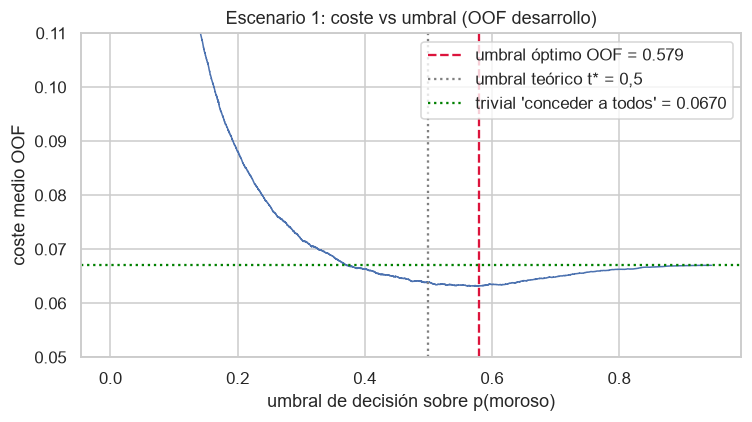

Umbral óptimo OOF: 0.5793 → coste OOF 0.0632 (en t=0,5: 0.0639)


In [126]:
NOMBRE_GANADOR = "LightGBM compacto (300x15)"
oof_ganador = oof[NOMBRE_GANADOR]

C_FP_1, C_FN_1 = 1, 1
t1_dev, c1_oof = umbral_optimo(y_dev, oof_ganador, C_FP_1, C_FN_1)

t_grid, c_grid = curva_coste(y_dev, oof_ganador, C_FP_1, C_FN_1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_grid[1:], c_grid[1:], lw=1)
ax.axvline(t1_dev, color="crimson", ls="--", label=f"umbral óptimo OOF = {t1_dev:.3f}")
ax.axvline(0.5, color="gray", ls=":", label="umbral teórico t* = 0,5")
ax.axhline(y_dev.mean(), color="green", ls=":", label=f"trivial 'conceder a todos' = {y_dev.mean():.4f}")
ax.set_xlabel("umbral de decisión sobre p(moroso)")
ax.set_ylabel("coste medio OOF")
ax.set_title("Escenario 1: coste vs umbral (OOF desarrollo)")
ax.set_ylim(0.05, 0.11)
ax.legend()
plt.tight_layout(); plt.show()

print(f"Umbral óptimo OOF: {t1_dev:.4f} → coste OOF {c1_oof:.4f} (en t=0,5: "
      f"{coste_medio(y_dev, (oof_ganador > 0.5).astype(int), 1, 1):.4f})")

In [127]:
# Evaluación única en test del escenario 1 (modelo reentrenado en desarrollo, umbral congelado)
modelo_dev = crea_lgbm().fit(X_dev, y_dev)
proba_test = modelo_dev.predict_proba(X_test)[:, 1]

pred1_test = (proba_test > t1_dev).astype(int)
coste1_test = coste_medio(y_test, pred1_test, C_FP_1, C_FN_1)

tp = ((pred1_test == 1) & (y_test == 1)).sum(); fp = ((pred1_test == 1) & (y_test == 0)).sum()
fn = ((pred1_test == 0) & (y_test == 1)).sum(); tn = ((pred1_test == 0) & (y_test == 0)).sum()
print(f"ESCENARIO 1 — coste medio en test: {coste1_test:.4f}  (trivial: {y_test.mean():.4f})")
print(f"Denegación: {pred1_test.mean():.2%} | recall morosos: {tp/(tp+fn):.1%} | precisión denegaciones: {tp/max(tp+fp,1):.1%}")
print(pd.DataFrame([[tn, fp], [fn, tp]],
                   index=["real 0", "real 1"], columns=["pred 0 (conceder)", "pred 1 (denegar)"]))

ESCENARIO 1 — coste medio en test: 0.0635  (trivial: 0.0670)
Denegación: 1.50% | recall morosos: 13.8% | precisión denegaciones: 61.8%
        pred 0 (conceder)  pred 1 (denegar)
real 0              19411               120
real 1               1209               194


### Interpretación de la sección 4

El coste de test es **0,0635 frente al 0,0668 trivial**: una mejora de solo el 5%. No es un
fallo del modelo (su AUC de 0,86 es razonable para credit scoring), es una propiedad del
escenario: con costes simétricos y un 6,7% de morosos, solo compensa denegar cuando
p(moroso) > 0,5, y **muy pocos clientes son tan claramente malos**, el modelo deniega solo al
1,5% y captura el 14% de los morosos. La curva de coste es casi plana entre 0,4 y 0,6, por eso
el óptimo empírico (0,58) difiere del teórico (0,5) sin apenas consecuencia en coste: en zonas
planas el umbral exacto es ruido estadístico, no señal. La lección de negocio: **con esta matriz
de coste, el crédito es un negocio de aceptar casi todo**, y el valor del modelo está en la cola
de scores altos. El escenario 2 cambia esto radicalmente.

## 5. Modelado — Escenario 2 (C_FP = 1, C_FN = 10)

Con la matriz asimétrica hay **dos palancas** posibles y las comparamos explícitamente:

- **Post-procesado**: mismo modelo neutro, umbral desplazado al óptimo de coste (teóricamente
  1/11 ≈ 0,091).
- **Entrenamiento cost-sensitive**: `scale_pos_weight=10` en LightGBM (equivale a ponderar
  cada moroso ×10 en la pérdida) y `class_weight={0:1, 1:10}` en la logística, cada uno con su
  propio umbral óptimo posterior.

La teoría dice que para un clasificador probabilístico bien calibrado ambas rutas convergen:
ponderar ×10 desplaza las probabilidades de modo que el umbral óptimo vuelve a ~0,5. La
pregunta empírica es si alguna gana en coste y qué se sacrifica por el camino.

In [128]:
C_FP_2, C_FN_2 = 1, 10
T_TEORICO_2 = C_FP_2 / (C_FP_2 + C_FN_2)   # 1/11 ≈ 0,0909

# OOF de las variantes cost-sensitive (mismos folds que en la sección 4)
oof["LightGBM compacto spw=10"] = cross_val_predict(
    crea_lgbm(scale_pos_weight=10), X_dev, y_dev, cv=cv, method="predict_proba")[:, 1]
oof["Logística cw={0:1,1:10}"] = cross_val_predict(
    crea_pipe_logistica(class_weight={0: 1, 1: 10}), X_dev, y_dev, cv=cv, method="predict_proba")[:, 1]

def evalua_estrategia(nombre_modelo, umbral, etiqueta):
    proba = oof[nombre_modelo]
    pred = (proba > umbral).astype(int)
    return {"estrategia": etiqueta, "umbral": umbral,
            "coste_OOF_E2": coste_medio(y_dev, pred, C_FP_2, C_FN_2),
            "denegación": pred.mean(),
            "Brier": brier_score_loss(y_dev, proba)}

t2_dev, _ = umbral_optimo(y_dev, oof_ganador, C_FP_2, C_FN_2)
t2_spw, _ = umbral_optimo(y_dev, oof["LightGBM compacto spw=10"], C_FP_2, C_FN_2)
t2_log, _ = umbral_optimo(y_dev, oof["Regresión logística L2"], C_FP_2, C_FN_2)
t2_lcw, _ = umbral_optimo(y_dev, oof["Logística cw={0:1,1:10}"], C_FP_2, C_FN_2)

tabla_e2 = pd.DataFrame([
    evalua_estrategia(NOMBRE_GANADOR, 0.5,        "A. LGBM neutro + umbral 0,5 (naive)"),
    evalua_estrategia(NOMBRE_GANADOR, T_TEORICO_2, "B. LGBM neutro + umbral teórico 1/11"),
    evalua_estrategia(NOMBRE_GANADOR, t2_dev,      "C. LGBM neutro + umbral empírico OOF"),
    evalua_estrategia("LightGBM compacto spw=10", 0.5,    "D. LGBM spw=10 + umbral 0,5"),
    evalua_estrategia("LightGBM compacto spw=10", t2_spw, "E. LGBM spw=10 + umbral empírico OOF"),
    evalua_estrategia("Regresión logística L2", t2_log,   "F. Logística neutra + umbral empírico"),
    evalua_estrategia("Logística cw={0:1,1:10}", t2_lcw,  "G. Logística cw10 + umbral empírico"),
]).set_index("estrategia").round(4)
tabla_e2

,umbral,coste_OOF_E2,denegación,Brier
estrategia,,,,
"A. LGBM neutro + umbral 0,5 (naive)",0.5000,0.5459,0.0238,0.0497
B. LGBM neutro + umbral teórico 1/11,0.0909,0.3371,0.1792,0.0497
C. LGBM neutro + umbral empírico OOF,0.0869,0.3347,0.1864,0.0497
"D. LGBM spw=10 + umbral 0,5",0.5000,0.3373,0.1715,0.1079
E. LGBM spw=10 + umbral empírico OOF,0.4561,0.3358,0.1951,0.1079
F. Logística neutra + umbral empírico,0.1008,0.3531,0.1682,0.0507
G. Logística cw10 + umbral empírico,0.5021,0.3444,0.1690,0.1155


**Interpretación de la tabla de trade-off** (el corazón cost-sensitive del proyecto):

- **El umbral naive de 0,5 (fila A) es un desastre**: coste 0,546, un 63% peor que el óptimo.
  Es el error clásico de ignorar la matriz de coste en la capa de decisión.
- **B vs C**: el umbral teórico 1/11 pierde solo ~2 milésimas frente al empírico. El modelo
  está **bien calibrado** (lo confirmamos gráficamente abajo), así que la teoría bayesiana de
  decisión funciona casi "de fábrica".
- **C vs E (la comparación pedida)**: entrenar con `scale_pos_weight=10` y re-optimizar el
  umbral **empata a milésimas** con el umbral puro sobre el modelo neutro. Ninguna palanca
  domina en coste. Pero hay dos efectos laterales de los pesos: (1) su umbral óptimo se
  desplaza a ~0,45, exactamente lo que predice la teoría (la ponderación ×10 "recoloca" el
  1/11 cerca de 0,5); (2) el **Brier se duplica**. Las salidas del modelo ponderado ya no son
  probabilidades reales de impago, sino puntuaciones deformadas. 
- La fila D muestra que confiar ciegamente en pesos + 0,5 tampoco es óptimo.
- **Decisión**: nos quedamos con **C ,  modelo neutro + umbral empírico**. Con coste empatado,
  desempatan las razones de gobernanza: un único modelo cuyas salidas son probabilidades
  auténticas sirve para ambos escenarios, para provisionar, para tarificar y para explicar
  ("su probabilidad de impago es del 12%" significa algo); mantener dos modelos ponderados
  distintos, con salidas incomparables entre sí, es deuda técnica sin retorno.

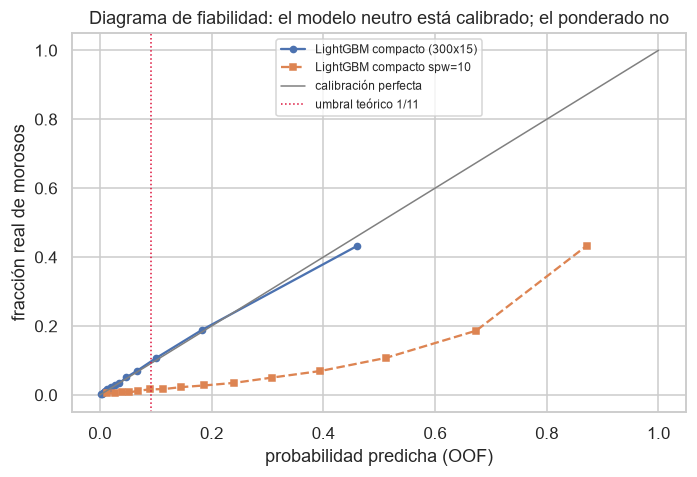

In [129]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for nombre, estilo in [(NOMBRE_GANADOR, "o-"), ("LightGBM compacto spw=10", "s--")]:
    frac_pos, media_pred = calibration_curve(y_dev, oof[nombre], n_bins=15, strategy="quantile")
    ax.plot(media_pred, frac_pos, estilo, ms=4, label=nombre)
ax.plot([0, 1], [0, 1], color="gray", lw=1, label="calibración perfecta")
ax.axvline(T_TEORICO_2, color="crimson", ls=":", lw=1, label="umbral teórico 1/11")
ax.set_xlabel("probabilidad predicha (OOF)")
ax.set_ylabel("fracción real de morosos")
ax.set_title("Diagrama de fiabilidad: el modelo neutro está calibrado; el ponderado no")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [130]:
# Evaluación única en test del escenario 2 (mismo modelo ya entrenado, umbral congelado OOF)
pred2_test = (proba_test > t2_dev).astype(int)
coste2_test = coste_medio(y_test, pred2_test, C_FP_2, C_FN_2)

tp = ((pred2_test == 1) & (y_test == 1)).sum(); fp = ((pred2_test == 1) & (y_test == 0)).sum()
fn = ((pred2_test == 0) & (y_test == 1)).sum(); tn = ((pred2_test == 0) & (y_test == 0)).sum()
print(f"ESCENARIO 2 — umbral OOF: {t2_dev:.4f} | coste medio en test: {coste2_test:.4f}  (trivial: {10*y_test.mean():.4f})")
print(f"Denegación: {pred2_test.mean():.2%} | recall morosos: {tp/(tp+fn):.1%} | precisión denegaciones: {tp/max(tp+fp,1):.1%}")
print(pd.DataFrame([[tn, fp], [fn, tp]],
                   index=["real 0", "real 1"], columns=["pred 0 (conceder)", "pred 1 (denegar)"]))

ESCENARIO 2 — umbral OOF: 0.0869 | coste medio en test: 0.3351  (trivial: 0.6702)
Denegación: 18.83% | recall morosos: 71.0% | precisión denegaciones: 25.3%
        pred 0 (conceder)  pred 1 (denegar)
real 0              16586              2945
real 1                407               996


### Interpretación de la sección 5

Coste de test **0,3351 frente al 0,668 trivial**: el modelo aporta un valor sustancial
(−50%), porque la matriz asimétrica hace que la detección de morosos sea el objetivo principal
de negocio. La matriz de confusión muestra claramente el intercambio asumido: para capturar el
71% de los morosos se deniega el crédito a 2.945 buenos pagadores, es decir, aproximadamente
**3 falsos positivos por cada moroso detectado**.

Con C_FN=10, este intercambio es rentable desde el punto de vista de la función de coste: cada
moroso correctamente evitado ahorra 10 unidades, mientras que cada buen pagador rechazado cuesta
1 unidad. Sin embargo, esta optimización traslada parte del coste a clientes solventes que son
rechazados, generando un impacto reputacional y potenciales problemas de equidad que la matriz de
coste no incorpora. Este punto se analiza de nuevo en §9 mediante el análisis por edad y en §12.

Metodológicamente, la coincidencia entre el coste OOF (0,335) y el coste test (0,335) confirma
que el umbral no está sobreajustado y que el procedimiento OOF ha funcionado correctamente.

## 6. Comparación de escenarios y sensibilidad a la matriz de coste

In [131]:
resumen_esc = pd.DataFrame({
    "Escenario 1 (1:1)": {
        "umbral": round(t1_dev, 4), "denegación_test": f"{pred1_test.mean():.2%}",
        "recall_morosos": f"{((pred1_test==1)&(y_test==1)).sum()/max((y_test==1).sum(),1):.1%}",
        "FP_test": int(((pred1_test==1)&(y_test==0)).sum()),
        "FN_test": int(((pred1_test==0)&(y_test==1)).sum()),
        "coste_test": round(coste1_test, 4), "coste_trivial": round(float(y_test.mean()), 4)},
    "Escenario 2 (1:10)": {
        "umbral": round(t2_dev, 4), "denegación_test": f"{pred2_test.mean():.2%}",
        "recall_morosos": f"{((pred2_test==1)&(y_test==1)).sum()/max((y_test==1).sum(),1):.1%}",
        "FP_test": int(((pred2_test==1)&(y_test==0)).sum()),
        "FN_test": int(((pred2_test==0)&(y_test==1)).sum()),
        "coste_test": round(coste2_test, 4), "coste_trivial": round(float(10*y_test.mean()), 4)},
})
resumen_esc

,Escenario 1 (1:1),Escenario 2 (1:10)
umbral,0.5793,0.0869
denegación_test,1.50%,18.83%
recall_morosos,13.8%,71.0%
FP_test,120,2945
FN_test,1209,407
coste_test,0.0635,0.3351
coste_trivial,0.067,0.6702


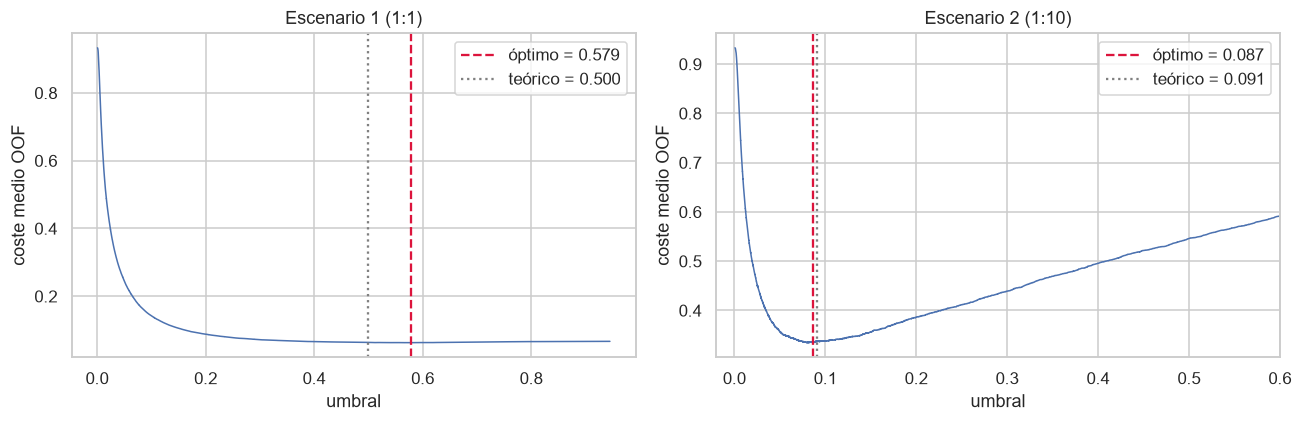

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (cfp, cfn, t_opt, titulo) in zip(axes, [(1, 1, t1_dev, "Escenario 1 (1:1)"),
                                                (1, 10, t2_dev, "Escenario 2 (1:10)")]):
    tg, cg = curva_coste(y_dev, oof_ganador, cfp, cfn)
    ax.plot(tg[1:], cg[1:], lw=1)
    ax.axvline(t_opt, color="crimson", ls="--", label=f"óptimo = {t_opt:.3f}")
    ax.axvline(cfp/(cfp+cfn), color="gray", ls=":", label=f"teórico = {cfp/(cfp+cfn):.3f}")
    ax.set_xlabel("umbral"); ax.set_ylabel("coste medio OOF"); ax.set_title(titulo); ax.legend()
axes[1].set_xlim(-0.02, 0.6)
plt.tight_layout(); plt.show()

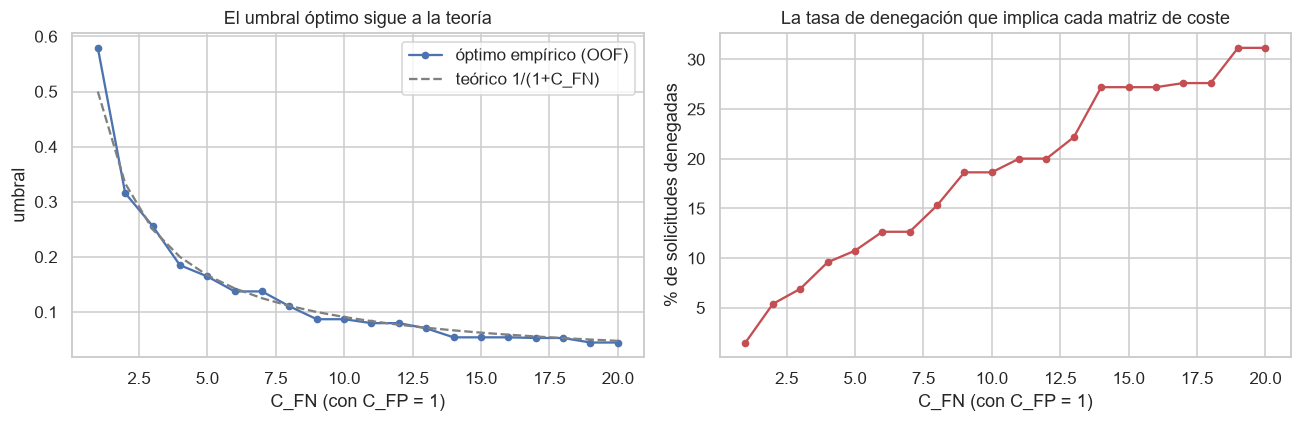

,C_FN,umbral_optimo,umbral_teorico,denegación,coste_OOF
0,1,0.5793,0.5000,0.0150,0.0632
1,2,0.3157,0.3333,0.0539,0.1124
2,3,0.2562,0.2500,0.0691,0.1518
3,4,0.1849,0.2000,0.0958,0.1869
4,5,0.1646,0.1667,0.1074,0.2166
5,6,0.1373,0.1429,0.1265,0.2434
6,7,0.1373,0.1250,0.1265,0.2696
7,8,0.1104,0.1111,0.1530,0.2934
8,9,0.0869,0.1000,0.1864,0.3151
9,10,0.0869,0.0909,0.1864,0.3347


In [133]:
# Sensibilidad: ¿cómo cambia la política óptima si el comité de riesgos cambia C_FN?
ratios = np.arange(1, 21)
sens = []
for r in ratios:
    t_r, c_r = umbral_optimo(y_dev, oof_ganador, 1, r)
    sens.append({"C_FN": r, "umbral_optimo": t_r, "umbral_teorico": 1/(1+r),
                 "denegación": (oof_ganador > t_r).mean(), "coste_OOF": c_r})
sens = pd.DataFrame(sens)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sens["C_FN"], sens["umbral_optimo"], "o-", ms=4, label="óptimo empírico (OOF)")
axes[0].plot(sens["C_FN"], sens["umbral_teorico"], "--", color="gray", label="teórico 1/(1+C_FN)")
axes[0].set_xlabel("C_FN (con C_FP = 1)"); axes[0].set_ylabel("umbral"); axes[0].legend()
axes[0].set_title("El umbral óptimo sigue a la teoría")
axes[1].plot(sens["C_FN"], 100*sens["denegación"], "o-", ms=4, color="#C44E52")
axes[1].set_xlabel("C_FN (con C_FP = 1)"); axes[1].set_ylabel("% de solicitudes denegadas")
axes[1].set_title("La tasa de denegación que implica cada matriz de coste")
plt.tight_layout(); plt.show()
sens.round(4)

### Interpretación de la sección 6

La comparación deja tres conclusiones:

1. **El "modelo" es score + política, y la política la fija la matriz de coste.** El mismo
   clasificador pasa de denegar el 1,5% (recall 14%) a denegar el 18,8% (recall 71%) solo
   cambiando C_FN de 1 a 10. La decisión más importante del sistema no la toma el algoritmo,
   la toma quien elige la matriz.
2. **La sensibilidad es fuerte al principio y se satura**: el barrido muestra que el salto
   grande de denegación ocurre entre C_FN=1 y C_FN≈8 (del 1,5% al ~17%); a partir de ahí
   duplicar la penalización apenas mueve la política. La elección "10" no es mágica: cualquier
   valor entre 8 y 15 produce políticas parecidas. Lo que sería imperdonable es no saber qué
   valor se está usando implícitamente (usar 0,5 equivale a declarar C_FN = C_FP).
3. **El umbral empírico sigue de cerca al teórico 1/(1+C_FN) en todo el rango**, la
   calibración del modelo se sostiene en toda la escala, no solo en los dos escenarios
   evaluados, lo que da confianza para renegociar la matriz sin reentrenar.

## 7. Auditoría (I): modelo subrogado con reglas

Un **subrogado global** es un modelo transparente entrenado para imitar las *decisiones* de la
caja negra (no la realidad): aquí, árboles de decisión poco profundos ajustados sobre la
predicción binaria del LightGBM en desarrollo. Dos matices metodológicos importantes:

- Imitamos la **decisión completa (score + umbral)** de cada escenario, no el score aislado:
  es lo que un regulador o un comité quiere entender ("¿a quién deniega este sistema?").
- La **fidelidad** (acuerdo subrogado ↔ caja negra) se mide en test, datos que ninguno de los
  dos ha visto, y la contrastamos con la fidelidad de un subrogado trivial que siempre dice
  "conceder", con clases desbalanceadas ese baseline ya parece altísimo y conviene no
  autoengañarse.

In [134]:
# --- Helper: extracción de reglas legibles de un árbol sklearn ---
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree

def reglas_desde_arbol(arbol, nombres, X_ref, decisiones_ref):
    """Convierte cada hoja del árbol en una regla 'SI ... ENTONCES ...' y la anota con
    su cobertura y su acuerdo con la caja negra sobre un conjunto de referencia."""
    t = arbol.tree_
    reglas = []
    def recorre(nodo, condiciones):
        if t.feature[nodo] == _tree.TREE_UNDEFINED:
            reglas.append((condiciones, int(np.argmax(t.value[nodo][0])), nodo))
            return
        f, u = nombres[t.feature[nodo]], t.threshold[nodo]
        recorre(t.children_left[nodo], condiciones + [f"{f} ≤ {u:.3g}"])
        recorre(t.children_right[nodo], condiciones + [f"{f} > {u:.3g}"])
    recorre(0, [])
    hoja_de = arbol.apply(X_ref)
    filas = []
    for condiciones, clase, nodo in reglas:
        m = hoja_de == nodo
        filas.append({"regla": " Y ".join(condiciones),
                      "decisión": "DENEGAR" if clase == 1 else "conceder",
                      "cobertura": m.mean(),
                      "acuerdo_caja_negra": (np.asarray(decisiones_ref)[m] == clase).mean() if m.any() else np.nan})
    return pd.DataFrame(filas).sort_values("cobertura", ascending=False).reset_index(drop=True)

print("Helper de reglas listo")

Helper de reglas listo


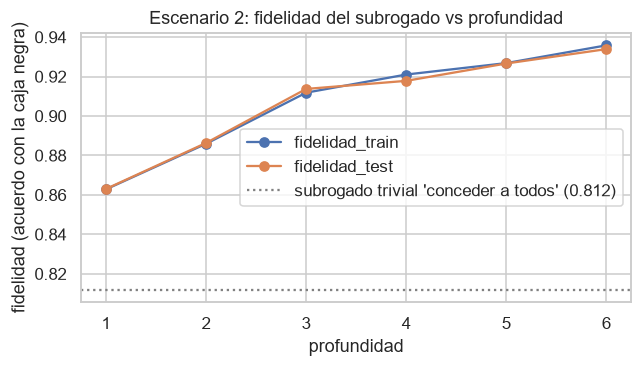

,fidelidad_train,fidelidad_test
profundidad,,
1,0.8628,0.8630
2,0.8859,0.8863
3,0.9118,0.9137
4,0.9210,0.9178
5,0.9268,0.9266
6,0.9358,0.9339


In [135]:
# Decisiones de la caja negra que el subrogado debe imitar
proba_dev_fit = modelo_dev.predict_proba(X_dev)[:, 1]
dec_dev_e2 = (proba_dev_fit > t2_dev).astype(int)
dec_test_e2 = (proba_test > t2_dev).astype(int)

fidelidades = []
for prof in [1, 2, 3, 4, 5, 6]:
    arbol = DecisionTreeClassifier(max_depth=prof, min_samples_leaf=200, random_state=SEED)
    arbol.fit(X_dev, dec_dev_e2)
    fidelidades.append({"profundidad": prof,
                        "fidelidad_train": (arbol.predict(X_dev) == dec_dev_e2).mean(),
                        "fidelidad_test": (arbol.predict(X_test) == dec_test_e2).mean()})
fidelidades = pd.DataFrame(fidelidades).set_index("profundidad").round(4)

fig, ax = plt.subplots(figsize=(6, 3.5))
fidelidades.plot(ax=ax, marker="o")
ax.axhline(1 - dec_test_e2.mean(), color="gray", ls=":",
           label=f"subrogado trivial 'conceder a todos' ({1 - dec_test_e2.mean():.3f})")
ax.set_ylabel("fidelidad (acuerdo con la caja negra)")
ax.set_title("Escenario 2: fidelidad del subrogado vs profundidad")
ax.legend()
plt.tight_layout(); plt.show()
fidelidades

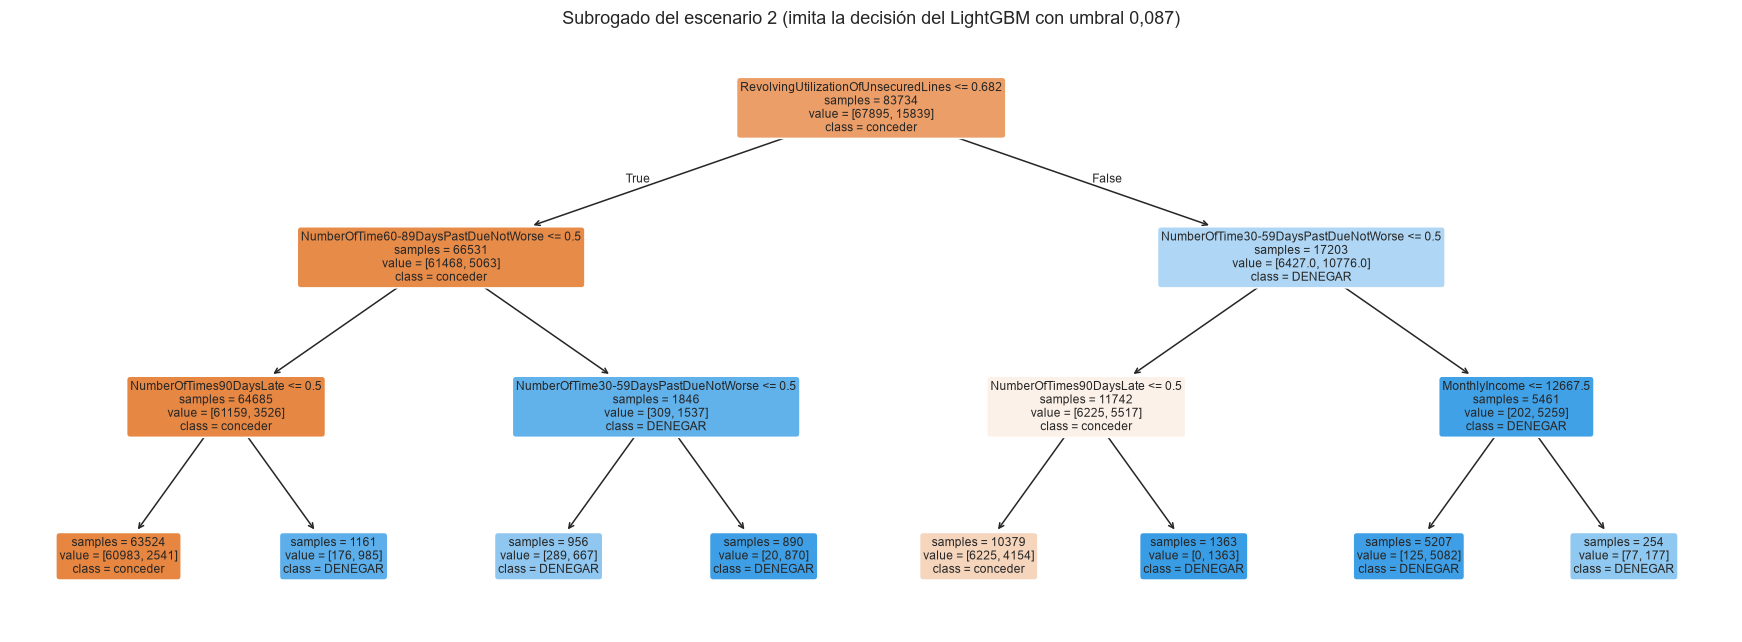

,regla,decisión,cobertura,acuerdo_caja_negra
0,RevolvingUtilizationOfUnsecuredLines ≤ 0.682 Y NumberOfTime60-89DaysPastDueNotWorse ≤ 0.5 Y NumberOfTimes90DaysLate ≤ 0.5,conceder,0.760,0.960
1,RevolvingUtilizationOfUnsecuredLines > 0.682 Y NumberOfTime30-59DaysPastDueNotWorse ≤ 0.5 Y NumberOfTimes90DaysLate ≤ 0.5,conceder,0.123,0.609
2,RevolvingUtilizationOfUnsecuredLines > 0.682 Y NumberOfTime30-59DaysPastDueNotWorse > 0.5 Y MonthlyIncome ≤ 1.27e+04,DENEGAR,0.062,0.978
3,RevolvingUtilizationOfUnsecuredLines > 0.682 Y NumberOfTime30-59DaysPastDueNotWorse ≤ 0.5 Y NumberOfTimes90DaysLate > 0.5,DENEGAR,0.018,0.995
4,RevolvingUtilizationOfUnsecuredLines ≤ 0.682 Y NumberOfTime60-89DaysPastDueNotWorse ≤ 0.5 Y NumberOfTimes90DaysLate > 0.5,DENEGAR,0.014,0.862
5,RevolvingUtilizationOfUnsecuredLines ≤ 0.682 Y NumberOfTime60-89DaysPastDueNotWorse > 0.5 Y NumberOfTime30-59DaysPastDueNotWor...,DENEGAR,0.011,0.687
6,RevolvingUtilizationOfUnsecuredLines ≤ 0.682 Y NumberOfTime60-89DaysPastDueNotWorse > 0.5 Y NumberOfTime30-59DaysPastDueNotWor...,DENEGAR,0.010,0.982
7,RevolvingUtilizationOfUnsecuredLines > 0.682 Y NumberOfTime30-59DaysPastDueNotWorse > 0.5 Y MonthlyIncome > 1.27e+04,DENEGAR,0.003,0.786


In [136]:
# Subrogado elegido para el escenario 2: profundidad 3 (equilibrio legibilidad/fidelidad)
subrogado_e2 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=200, random_state=SEED)
subrogado_e2.fit(X_dev, dec_dev_e2)

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(subrogado_e2, feature_names=list(X_dev.columns), filled=True, rounded=True,
          class_names=["conceder", "DENEGAR"], impurity=False, fontsize=8, ax=ax)
plt.title("Subrogado del escenario 2 (imita la decisión del LightGBM con umbral 0,087)")
plt.tight_layout(); plt.show()

reglas_e2 = reglas_desde_arbol(subrogado_e2, list(X_dev.columns), X_test, dec_test_e2)
pd.options.display.max_colwidth = 130
reglas_e2.round(3)

In [137]:
# Auditoría fina de fidelidad del subrogado E2: global, por decisión y cerca del umbral
from sklearn.metrics import confusion_matrix

pred_sub_e2 = subrogado_e2.predict(X_test)
acuerdo_e2 = pred_sub_e2 == dec_test_e2

mat_conf_sub = pd.DataFrame(
    confusion_matrix(dec_test_e2, pred_sub_e2, labels=[0, 1]),
    index=["caja negra: conceder", "caja negra: DENEGAR"],
    columns=["subrogado: conceder", "subrogado: DENEGAR"],
)

fidelidad_por_decision = pd.DataFrame({
    "n": [int((dec_test_e2 == 0).sum()), int((dec_test_e2 == 1).sum())],
    "fidelidad": [
        acuerdo_e2[dec_test_e2 == 0].mean(),
        acuerdo_e2[dec_test_e2 == 1].mean(),
    ],
    "peso_en_test": [
        (dec_test_e2 == 0).mean(),
        (dec_test_e2 == 1).mean(),
    ],
}, index=["caja negra concede", "caja negra deniega"])

# Cerca del umbral la decisión es más inestable; ahí el subrogado suele sufrir más.
margen_umbral = 0.02
mask_cerca_umbral = np.abs(proba_test - t2_dev) <= margen_umbral
fidelidad_cerca = pd.DataFrame({
    "grupo": [f"|p - umbral| <= {margen_umbral:.2f}", f"|p - umbral| > {margen_umbral:.2f}"],
    "n": [int(mask_cerca_umbral.sum()), int((~mask_cerca_umbral).sum())],
    "fidelidad": [acuerdo_e2[mask_cerca_umbral].mean(), acuerdo_e2[~mask_cerca_umbral].mean()],
    "denegación_caja_negra": [dec_test_e2[mask_cerca_umbral].mean(), dec_test_e2[~mask_cerca_umbral].mean()],
}).set_index("grupo")

resumen_reglas_e2 = pd.DataFrame({
    "n_reglas": [len(reglas_e2)],
    "cobertura_media": [reglas_e2["cobertura"].mean()],
    "cobertura_max": [reglas_e2["cobertura"].max()],
    "cobertura_reglas_DENEGAR": [reglas_e2.loc[reglas_e2["decisión"] == "DENEGAR", "cobertura"].sum()],
    "cobertura_reglas_conceder": [reglas_e2.loc[reglas_e2["decisión"] == "conceder", "cobertura"].sum()],
})

print("Matriz de confusión: caja negra vs subrogado (escenario 2)")
display(mat_conf_sub)

print("Fidelidad separada por decisión de la caja negra")
display(fidelidad_por_decision.round(3))

print("Fidelidad cerca/lejos del umbral de decisión")
display(fidelidad_cerca.round(3))

print("Número de reglas y cobertura")
display(resumen_reglas_e2.round(3))


Matriz de confusión: caja negra vs subrogado (escenario 2)


,subrogado: conceder,subrogado: DENEGAR
caja negra: conceder,16837,156
caja negra: DENEGAR,1650,2291


Fidelidad separada por decisión de la caja negra


,n,fidelidad,peso_en_test
caja negra concede,16993,0.991,0.812
caja negra deniega,3941,0.581,0.188


Fidelidad cerca/lejos del umbral de decisión


,n,fidelidad,denegación_caja_negra
grupo,,,
|p - umbral| <= 0.02,1693,0.619,0.406
|p - umbral| > 0.02,19241,0.940,0.169


Número de reglas y cobertura


,n_reglas,cobertura_media,cobertura_max,cobertura_reglas_DENEGAR,cobertura_reglas_conceder
0,8,0.125,0.76,0.117,0.883


**Auditoría fina de fidelidad.** La fidelidad global no basta. En un problema desbalanceado,
un subrogado puede parecer excelente simplemente porque la mayoría de solicitudes se conceden. Por
eso miramos cuatro capas adicionales: matriz de confusión caja negra ↔ subrogado, fidelidad separada
en decisiones de conceder y denegar, fidelidad en clientes cerca del umbral y número/cobertura de
las reglas. Si el subrogado falla justo en las denegaciones o en la frontera de decisión, su utilidad
como explicación operativa es menor aunque la fidelidad media sea alta.


In [138]:
# Mismo ejercicio para el escenario 1 — y la trampa de la fidelidad con clases desbalanceadas
dec_dev_e1 = (proba_dev_fit > t1_dev).astype(int)
dec_test_e1 = (proba_test > t1_dev).astype(int)
subrogado_e1 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=200, random_state=SEED)
subrogado_e1.fit(X_dev, dec_dev_e1)

fid_e1 = (subrogado_e1.predict(X_test) == dec_test_e1).mean()
fid_trivial = 1 - dec_test_e1.mean()
denegados = dec_test_e1 == 1
fid_en_denegados = (subrogado_e1.predict(X_test)[denegados] == 1).mean()
print(f"Escenario 1 — fidelidad global del subrogado: {fid_e1:.4f}")
print(f"Pero el subrogado trivial 'conceder a todos' ya tendría: {fid_trivial:.4f}")
print(f"Fidelidad SOLO sobre las denegaciones de la caja negra: {fid_en_denegados:.1%}")
reglas_e1 = reglas_desde_arbol(subrogado_e1, list(X_dev.columns), X_test, dec_test_e1)
reglas_e1.round(3)

Escenario 1 — fidelidad global del subrogado: 0.9897
Pero el subrogado trivial 'conceder a todos' ya tendría: 0.9850
Fidelidad SOLO sobre las denegaciones de la caja negra: 47.5%


,regla,decisión,cobertura,acuerdo_caja_negra
0,NumberOfTimes90DaysLate ≤ 1.5 Y NumberOfTime60-89DaysPastDueNotWorse ≤ 1.5 Y NumberOfTime30-59DaysPastDueNotWorse ≤ 2.5,conceder,0.957,0.998
1,NumberOfTimes90DaysLate ≤ 1.5 Y NumberOfTime60-89DaysPastDueNotWorse ≤ 1.5 Y NumberOfTime30-59DaysPastDueNotWorse > 2.5,conceder,0.015,0.877
2,NumberOfTimes90DaysLate > 1.5 Y NumberOfTime60-89DaysPastDueNotWorse ≤ 0.5 Y NumberOfTime30-59DaysPastDueNotWorse ≤ 0.5,conceder,0.006,0.878
3,NumberOfTimes90DaysLate ≤ 1.5 Y NumberOfTime60-89DaysPastDueNotWorse > 1.5 Y NumberOfTimes90DaysLate ≤ 0.5,conceder,0.005,0.861
4,NumberOfTimes90DaysLate > 1.5 Y NumberOfTime60-89DaysPastDueNotWorse ≤ 0.5 Y NumberOfTime30-59DaysPastDueNotWorse > 0.5,conceder,0.005,0.635
5,NumberOfTimes90DaysLate > 1.5 Y NumberOfTime60-89DaysPastDueNotWorse > 0.5 Y DebtRatio > 0.346,DENEGAR,0.005,0.860
6,NumberOfTimes90DaysLate > 1.5 Y NumberOfTime60-89DaysPastDueNotWorse > 0.5 Y DebtRatio ≤ 0.346,DENEGAR,0.005,0.636
7,NumberOfTimes90DaysLate ≤ 1.5 Y NumberOfTime60-89DaysPastDueNotWorse > 1.5 Y NumberOfTimes90DaysLate > 0.5,conceder,0.002,0.617


### Interpretación de la sección 7

**El banco que deniega según el escenario 2 se puede resumir en tres preguntas**: ¿ha tenido
retrasos de 90 días? ¿o de 60-89? ¿y cuánta tarjeta consume? El subrogado de profundidad 3
alcanza una fidelidad de **91,4% en test** (frente al 81,2% del trivial), y sus reglas de mayor
cobertura son exactamente las que un analista de riesgos esperaría: *"utilización ≤ 0,68 y sin
retrasos de 60-89 ni de 90 días → conceder"* cubre a la mayoría de la cartera con acuerdo
altísimo, y las denegaciones se concentran en *"algún retraso previo"* o *"utilización alta con
retrasos de 30-59 días"*. Aumentar la profundidad del subrogado a 5 solo mejora la fidelidad en aproximadamente 1,3 puntos,
pero genera 32 hojas y reduce de forma clara la interpretabilidad del modelo. Por tanto, la
profundidad 3 ofrece un equilibrio más adecuado entre fidelidad e interpretabilidad.

La auditoría fina confirma si esa fidelidad es de verdad útil: la matriz de confusión muestra qué
decisiones del LightGBM copia o cambia el subrogado. La fidelidad separada por `conceder` y
`DENEGAR` evita que la clase mayoritaria esconda errores. La fidelidad cerca del umbral mide justo
la zona donde una explicación debe ser más prudente, y el número/cobertura de reglas dice si el
árbol sigue siendo legible o si estamos comprando fidelidad a costa de interpretabilidad.

Hay dos advertencias importantes. En primer lugar, la **fidelidad del escenario 1 (99,0%) debe
interpretarse con cautela**: como la caja negra solo deniega al 1,5% de los clientes, un subrogado
trivial que concediera casi siempre ya alcanzaría una fidelidad cercana al 98,5%. Por tanto, la
fidelidad global no es suficiente para evaluar la calidad del subrogado. En contextos con clases
muy desbalanceadas, es necesario analizar también la fidelidad por clase y, en particular, comprobar
si el subrogado reproduce correctamente las denegaciones reales del modelo.

En segundo lugar, el subrogado describe **el comportamiento del modelo, no la realidad causal del
problema**. Sus reglas explican cómo aproxima las decisiones del LightGBM, pero no permiten concluir
por sí solas por qué una persona acaba presentando un impago. Por esta razón, no debe utilizarse como
política oficial de concesión de crédito: en el escenario 2, un 8,6% de las decisiones del
subrogado difieren de las de la caja negra. Su función adecuada es servir como herramienta de
interpretación para auditores y comités de riesgo, facilitando una visión resumida del modelo sin
sustituir al sistema de decisión original.

## 8. Auditoría (II): contrafactuales — "¿por qué se me deniega y qué puedo hacer?"

Un contrafactual responde una pregunta clave desde el punto de vista regulatorio y operativo:
**qué cambio mínimo en el expediente habría modificado la decisión del modelo**. En esta sección
trabajamos con la **política del escenario 2** (denegar si p > 0,087), porque es la que genera un
volumen de denegaciones suficientemente realista para analizar explicaciones individuales.

**Selección de casos**: se analizan 6 clientes reales del conjunto de test, elegidos mediante
criterios explícitos para cubrir situaciones relevantes y no solo ejemplos evidentes. Entre los
clientes de clase real 1 (morosos) incluimos: un cliente denegado con confianza muy alta, un
cliente denegado cerca del umbral y un **falso negativo** (moroso aprobado), que representa el
tipo de error más costoso bajo la matriz del escenario 2. Entre los clientes de clase real 0
(buenos pagadores) incluimos: un **falso positivo** claro, un cliente denegado cerca del umbral
y un cliente aprobado con score muy favorable.

Aplicamos además una restricción práctica: se excluyen casos con valores ausentes, códigos
anómalos 96/98 o utilizaciones superiores a 1,3. Esta decisión evita construir contrafactuales
sobre registros de baja calidad, ya que en esos casos los cambios recomendados podrían reflejar
artefactos de datos más que alternativas realistas para el cliente (§2.5).

**Dos generadores de contrafactuales**, que después contrastamos entre sí y con las técnicas de
explicabilidad de la sección 9:

1. **Búsqueda exhaustiva propia**: enumera combinaciones de 1 a 4 cambios sobre rejillas de
   valores plausibles y devuelve las soluciones válidas con menor número de cambios y menor
   distancia. Es un procedimiento determinista y garantiza que la probabilidad final queda por
   debajo del umbral de decisión de nuestra política.

2. **DiCE** (`dice-ml`, método aleatorio): se utiliza como generador alternativo para comprobar
   si una herramienta estándar produce recomendaciones coherentes con la búsqueda propia. Al
   revisar su comportamiento observamos que, con `desired_class=0`, DiCE puede reajustar
   internamente el `stopping_threshold` si no se especifica correctamente. Por ello se fija de
   forma explícita nuestro umbral de decisión, 0,087, para asegurar que los contrafactuales
   generados correspondan realmente a clientes aprobados bajo la política del escenario 2.

Este contraste permite auditar no solo las decisiones del modelo, sino también la consistencia de
las herramientas de explicación utilizadas.

In [139]:
# Selección determinista de los 6 clientes
validos = X_test.dropna()
validos = validos[(validos["flag_mora_extrema"] == 0) &
                  (validos["RevolvingUtilizationOfUnsecuredLines"] <= 1.3)]
p_val = pd.Series(modelo_dev.predict_proba(validos)[:, 1], index=validos.index)
y_val = y_test.loc[validos.index]

def elige(mask, criterio):
    cand = p_val[mask]
    if criterio == "max": return cand.idxmax()
    if criterio == "min": return cand.idxmin()
    return (cand - t2_dev).abs().idxmin()          # el más cercano al umbral

clientes = {
    "C1 (real 1, denegado claro)":   elige((y_val == 1) & (p_val > 0.5), "max"),
    "C2 (real 1, denegado límite)":  elige((y_val == 1) & (p_val > t2_dev) & (p_val < 0.25), "cerca"),
    "C3 (real 1, FN: aprobado)":     elige((y_val == 1) & (p_val < t2_dev), "max"),
    "C4 (real 0, FP: denegado)":     elige((y_val == 0) & (p_val > 0.4), "max"),
    "C5 (real 0, denegado límite)":  elige((y_val == 0) & (p_val > t2_dev) & (p_val < 0.25), "cerca"),
    "C6 (real 0, aprobado claro)":   elige((y_val == 0), "min"),
}

perfil = validos.loc[list(clientes.values())].drop(columns=[c for c in validos.columns if c.startswith("flag_")])
perfil.insert(0, "cliente", list(clientes.keys()))
perfil["p_mora"] = p_val[list(clientes.values())].round(4).values
perfil["decisión_E2"] = np.where(perfil["p_mora"] > t2_dev, "DENEGAR", "conceder")
perfil["clase_real"] = y_val[list(clientes.values())].values
perfil.set_index("cliente")

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,p_mora,decisión_E2,clase_real
cliente,,,,,,,,,,,,,
"C1 (real 1, denegado claro)",0.919246,61,5,1.032653,6124.0,16,0,8,5,0.0,0.9075,DENEGAR,1
"C2 (real 1, denegado límite)",0.414402,63,1,0.003599,2500.0,1,0,0,0,2.0,0.0877,DENEGAR,1
"C3 (real 1, FN: aprobado)",0.066604,61,0,1.283396,800.0,12,1,1,0,0.0,0.0869,DENEGAR,1
"C4 (real 0, FP: denegado)",0.910591,43,4,1.022866,22259.0,16,3,9,1,0.0,0.8452,DENEGAR,0
"C5 (real 0, denegado límite)",0.936177,46,0,0.271955,6000.0,2,0,0,0,1.0,0.0870,DENEGAR,0
"C6 (real 0, aprobado claro)",0.056159,77,0,0.025815,38000.0,4,0,1,0,0.0,0.0011,conceder,0


La tabla ya cuenta historias: **C1** (61 años) acumula 10 retrasos recientes con la tarjeta
al 92% , denegación clarísima (p=0,91) y efectivamente impagó. **C4** (43 años, ingresos de
22.259) es el caso incómodo: 3 retrasos de 90 días y utilización al 91% le dan p=0,85, pero en
la realidad pagó , es el falso positivo arquetípico del escenario 2. **C2, C3 y C5** viven
pegados al umbral (p ≈ 0,087): dos cayeron del lado de la denegación y uno (C3, que luego
impagó) se nos coló por milésimas. **C6** (77 años, utilización 6%, sin retrasos) es el
aprobado de libro.

In [140]:
# --- Helper: búsqueda exhaustiva de contrafactuales (determinista, consciente del umbral) ---
import itertools

REJILLAS = {
    "RevolvingUtilizationOfUnsecuredLines": [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8],
    "DebtRatio": [0.0, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0],
    "MonthlyIncome": [1500, 3000, 5400, 8000, 12000, 20000],
    "NumberOfOpenCreditLinesAndLoans": [0, 2, 5, 8, 12, 20],
    "NumberRealEstateLoansOrLines": [0, 1, 2, 4],
    "NumberOfTime30-59DaysPastDueNotWorse": [0, 1, 2],
    "NumberOfTime60-89DaysPastDueNotWorse": [0, 1, 2],
    "NumberOfTimes90DaysLate": [0, 1, 2],
}
ESCALA = {c: max(X_dev[c].dropna().std(), 1e-6) for c in REJILLAS}

def busca_contrafactuales(x0, modelo, umbral, k_max=4, top=3, sentido="bajar"):
    """Enumera cambios de 1..k_max variables accionables sobre rejillas plausibles.
    Devuelve los contrafactuales válidos (p<umbral si sentido='bajar'; p>umbral si 'subir')
    ordenados por (nº de cambios, distancia normalizada). Sin aleatoriedad: reproducible."""
    candidatos = []
    for k in range(1, k_max + 1):
        for combo in itertools.combinations(REJILLAS, k):
            for valores in itertools.product(*[REJILLAS[c] for c in combo]):
                if all(np.isclose(x0[c], v) for c, v in zip(combo, valores)):
                    continue
                candidatos.append(dict(zip(combo, valores)))
    Xc = pd.DataFrame([x0.to_dict()] * len(candidatos))
    for i, cambio in enumerate(candidatos):
        for c, v in cambio.items():
            Xc.iloc[i, Xc.columns.get_loc(c)] = v
    Xc = Xc[x0.index.tolist()]
    p = modelo.predict_proba(Xc)[:, 1]
    ok = p < umbral if sentido == "bajar" else p > umbral
    res = []
    for i in np.flatnonzero(ok):
        cambio = {c: v for c, v in candidatos[i].items() if not np.isclose(x0[c], v)}
        if not cambio:
            continue
        dist = sum(abs(x0[c] - v) / ESCALA[c] for c, v in cambio.items())
        res.append((len(cambio), dist, p[i], cambio))
    res.sort(key=lambda r: (r[0], r[1]))
    vistos, finales = set(), []
    for n, d, p_, cambio in res:
        clave = tuple(sorted(cambio))
        if clave in vistos:
            continue
        vistos.add(clave)
        finales.append({"n_cambios": n, "p_contrafactual": round(float(p_), 4), "cambios": cambio})
        if len(finales) == top:
            break
    return finales

def muestra_cfs(nombre, idx, cfs):
    x0 = X_test.loc[idx]
    print(f"--- {nombre} (p actual = {modelo_dev.predict_proba(X_test.loc[[idx]])[:, 1][0]:.4f}) ---")
    if not cfs:
        print("  SIN contrafactual válido dentro de los límites de plausibilidad")
    for j, cf in enumerate(cfs):
        cambios = ", ".join(f"{c}: {x0[c]:.3g} → {v:.4g}" for c, v in cf["cambios"].items())
        print(f"  CF{j+1} ({cf['n_cambios']} cambio(s), p → {cf['p_contrafactual']}): {cambios}")

print("Buscador de contrafactuales listo")

Buscador de contrafactuales listo


In [141]:
# Contrafactuales (búsqueda propia) para los 4 clientes DENEGADOS bajo la política E2
resultados_cf = {}
for nombre in ["C1 (real 1, denegado claro)", "C2 (real 1, denegado límite)",
               "C4 (real 0, FP: denegado)", "C5 (real 0, denegado límite)"]:
    idx = clientes[nombre]
    resultados_cf[nombre] = busca_contrafactuales(validos.loc[idx], modelo_dev, t2_dev)
    muestra_cfs(nombre, idx, resultados_cf[nombre])
    print()

--- C1 (real 1, denegado claro) (p actual = 0.9075) ---
  CF1 (3 cambio(s), p → 0.0798): RevolvingUtilizationOfUnsecuredLines: 0.919 → 0, NumberOfTime30-59DaysPastDueNotWorse: 5 → 0, NumberOfTime60-89DaysPastDueNotWorse: 5 → 0
  CF2 (4 cambio(s), p → 0.0762): RevolvingUtilizationOfUnsecuredLines: 0.919 → 0.4, DebtRatio: 1.03 → 0.2, MonthlyIncome: 6.12e+03 → 2e+04, NumberOfTime60-89DaysPastDueNotWorse: 5 → 0
  CF3 (4 cambio(s), p → 0.0836): RevolvingUtilizationOfUnsecuredLines: 0.919 → 0.05, DebtRatio: 1.03 → 0.2, NumberOfOpenCreditLinesAndLoans: 16 → 0, NumberOfTime60-89DaysPastDueNotWorse: 5 → 0

--- C2 (real 1, denegado límite) (p actual = 0.0877) ---
  CF1 (1 cambio(s), p → 0.083): DebtRatio: 0.0036 → 0
  CF2 (1 cambio(s), p → 0.0829): RevolvingUtilizationOfUnsecuredLines: 0.414 → 0.4
  CF3 (1 cambio(s), p → 0.0726): MonthlyIncome: 2.5e+03 → 5400

--- C4 (real 0, FP: denegado) (p actual = 0.8452) ---
  SIN contrafactual válido dentro de los límites de plausibilidad

--- C5 (real 0, 

In [142]:
# Contraste con DiCE (fresco + semilla en cada llamada para reproducibilidad;
# stopping_threshold = NUESTRO umbral, no el 0,5/0,25 por defecto — ver nota de la intro)
import io, contextlib
import dice_ml

datos_dice = X_dev.dropna().copy()
datos_dice[TARGET] = y_dev.loc[datos_dice.index].values
interfaz_datos = dice_ml.Data(dataframe=datos_dice,
                              continuous_features=[c for c in X_dev.columns if not c.startswith("flag_")],
                              outcome_name=TARGET)
interfaz_modelo = dice_ml.Model(model=modelo_dev, backend="sklearn")

ACCIONABLES = list(REJILLAS)   # edad, dependientes y flags quedan fijos: no son accionables
RANGOS_PLAUSIBLES = {"RevolvingUtilizationOfUnsecuredLines": [0, 1.2], "DebtRatio": [0, 2],
                     "MonthlyIncome": [400, 30000], "NumberOfOpenCreditLinesAndLoans": [0, 30],
                     "NumberRealEstateLoansOrLines": [0, 10],
                     "NumberOfTime30-59DaysPastDueNotWorse": [0, 6],
                     "NumberOfTime60-89DaysPastDueNotWorse": [0, 6],
                     "NumberOfTimes90DaysLate": [0, 6]}

dice_cf = {}
for nombre in resultados_cf:
    idx = clientes[nombre]
    explicador = dice_ml.Dice(interfaz_datos, interfaz_modelo, method="random")
    with contextlib.redirect_stderr(io.StringIO()):       # silencia la barra de progreso
        salida = explicador.generate_counterfactuals(
            validos.loc[[idx]], total_CFs=3, desired_class=0,
            stopping_threshold=t2_dev, features_to_vary=ACCIONABLES,
            permitted_range=RANGOS_PLAUSIBLES, random_seed=SEED)
    cf_df = salida.cf_examples_list[0].final_cfs_df
    dice_cf[nombre] = cf_df
    x0 = validos.loc[idx]
    p_cfs = modelo_dev.predict_proba(cf_df[X_dev.columns])[:, 1]
    assert (p_cfs < t2_dev).all(), "algún CF de DiCE no cruza el umbral de la política"
    print(f"--- DiCE, {nombre} ---")
    for j in range(len(cf_df)):
        cambios = ", ".join(f"{c}: {x0[c]:.3g} → {cf_df.iloc[j][c]:.4g}" for c in ACCIONABLES
                            if not np.isclose(x0[c], cf_df.iloc[j][c], atol=1e-4))
        print(f"  CF{j+1} (p → {p_cfs[j]:.4f}): {cambios}")
    print()

--- DiCE, C1 (real 1, denegado claro) ---
  CF1 (p → 0.0798): RevolvingUtilizationOfUnsecuredLines: 0.919 → 0, NumberOfTime30-59DaysPastDueNotWorse: 5 → 0, NumberOfTime60-89DaysPastDueNotWorse: 5 → 0
  CF2 (p → 0.0676): RevolvingUtilizationOfUnsecuredLines: 0.919 → 0, MonthlyIncome: 6.12e+03 → 1150, NumberOfTime30-59DaysPastDueNotWorse: 5 → 0, NumberOfTime60-89DaysPastDueNotWorse: 5 → 0
  CF3 (p → 0.0629): RevolvingUtilizationOfUnsecuredLines: 0.919 → 0, MonthlyIncome: 6.12e+03 → 1150, NumberOfOpenCreditLinesAndLoans: 16 → 5, NumberOfTime30-59DaysPastDueNotWorse: 5 → 0, NumberOfTime60-89DaysPastDueNotWorse: 5 → 0

--- DiCE, C2 (real 1, denegado límite) ---
  CF1 (p → 0.0504): NumberOfOpenCreditLinesAndLoans: 1 → 7
  CF2 (p → 0.0382): RevolvingUtilizationOfUnsecuredLines: 0.414 → 0.1, MonthlyIncome: 2.5e+03 → 1922
  CF3 (p → 0.0779): RevolvingUtilizationOfUnsecuredLines: 0.414 → 0.1, NumberRealEstateLoansOrLines: 0 → 5

--- DiCE, C4 (real 0, FP: denegado) ---
  CF1 (p → 0.0633): Revolvi

### La respuesta al cliente, redactada (la pregunta literal del enunciado)

Si un cliente pide explicaciones sobre por qué se le deniega el crédito, esta es la información
que le daríamos, motivos principales de la decisión + cambios concretos que la invertirían,
que es lo que exigen tanto el GDPR (derecho a explicación en decisiones automatizadas) como la
práctica de *adverse action notices*. Cartas basadas en los contrafactuales de arriba:

- **A C1** (61 años, tarjeta al 92%, 5 retrasos de 30-59 días y 5 de 60-89 en los últimos 2
 años): *"Su solicitud se ha denegado principalmente por los diez retrasos de pago registrados
 en los últimos dos años y por el uso casi completo (92%) de sus líneas de crédito actuales.
 Para una decisión favorable necesitaríamos un historial reciente sin retrasos, lo que
 requiere tiempo, típicamente los dos años de la ventana de evaluación, y una utilización de
 tarjetas por debajo del 40%. Con su nivel de ingresos no hay otro cambio (avales, más
 ingresos) que por sí solo revierta la decisión."* (Nota: el modelo acertó; este
 cliente impagó).

- **A C2** (63 años, tarjeta al 41%, 1 retraso de 30-59 días, ingresos 2.500): *"Su solicitud
 quedó marginalmente por debajo del corte (probabilidad estimada 8,8% frente al límite 8,7%).
 Pesan el retraso de pago del último periodo y unos ingresos declarados bajos: acreditando
 ingresos en torno a 5.400 o reduciendo la utilización de su tarjeta del 41% a menos del 40%,
 la solicitud se aprobaría. Le invitamos a re-solicitar aportando esa documentación."* (Nota:
 también impagó; el umbral estuvo bien puesto por poco).
 
- **A C4** (43 años, ingresos 22.259, tarjeta al 91%, 3 retrasos de 90 días + 5 menores): *"La
 denegación se debe esencialmente a su historial de pagos: tres retrasos de más de 90 días y
 cinco menores en dos años, combinados con una utilización del 91% de sus líneas. Debemos ser
 transparentes: ningún cambio inmediato en su solicitud (ingresos, deudas, número de cuentas)
 revierte por sí solo la decisión, nuestro análisis exhaustivo no encuentra combinaciones
 realistas de menos de cinco cambios simultáneos. La vía práctica es el tiempo: mantener los
 pagos al día hasta que los retrasos salgan de la ventana de dos años, y entretanto reducir el
 uso de tarjeta por debajo del 30%."* (Nota: este cliente en realidad **pagó**. Es un
 falso positivo estructural, el precio humano de la matriz 1:10 (ver §9 y §12)).

- **A C5** (46 años, tarjeta al 94%, historial limpio, ingresos 6.000): *"El único factor
 relevante en su denegación es la utilización del 94% de sus líneas de crédito. Reduciéndola
 por debajo del 60%, por ejemplo amortizando parte del saldo de tarjeta, la solicitud pasaría
 a aprobarse. Ningún otro aspecto de su expediente (historial de pagos impecable, deudas
 moderadas) pesa en contra."* (Nota: la denegación más evitable de las cuatro: un solo cambio
 accionable la invierte).

In [143]:
# Contrafactuales INVERSOS para los aprobados: ¿qué habría hecho denegarles?
for nombre in ["C3 (real 1, FN: aprobado)", "C6 (real 0, aprobado claro)"]:
    idx = clientes[nombre]
    cfs = busca_contrafactuales(X_test.loc[idx], modelo_dev, t2_dev, sentido="subir", k_max=2)
    resultados_cf[nombre] = cfs
    muestra_cfs(nombre, idx, cfs)
    print()

--- C3 (real 1, FN: aprobado) (p actual = 0.0869) ---
  CF1 (1 cambio(s), p → 0.0949): RevolvingUtilizationOfUnsecuredLines: 0.0666 → 0.05
  CF2 (1 cambio(s), p → 0.1209): DebtRatio: 1.28 → 0.5
  CF3 (1 cambio(s), p → 0.0919): MonthlyIncome: 800 → 1500

--- C6 (real 0, aprobado claro) (p actual = 0.0011) ---
  CF1 (2 cambio(s), p → 0.1137): DebtRatio: 0.0258 → 0.35, NumberOfTimes90DaysLate: 0 → 2
  CF2 (2 cambio(s), p → 0.105): RevolvingUtilizationOfUnsecuredLines: 0.0562 → 0, NumberOfTimes90DaysLate: 0 → 2
  CF3 (2 cambio(s), p → 0.0946): NumberOfTime60-89DaysPastDueNotWorse: 0 → 1, NumberOfTimes90DaysLate: 0 → 1



### Interpretación de la sección 8

Lo que los contrafactuales revelan **del modelo** (y no de los clientes) es lo más valioso de
la sección:

- **Coherencia general**: ambos generadores (búsqueda propia y DiCE) coinciden en el fondo.
  Las palancas dominantes son utilización de tarjeta e historial de retrasos, con ingresos como
  palanca secundaria. Para C1, DiCE y nuestra búsqueda dan exactamente el mismo contrafactual
  mínimo de 3 cambios.
- **No-monotonías sospechosas**: DiCE aprueba a C2 *abriéndole* 6 líneas de crédito más (1→7,
  p pasa de 0,088 a 0,050) y a C5 *bajándole* los ingresos de 6.000 a 4.537. Son atajos
  estadísticos (expedientes "finos" con pocas líneas parecen arriesgados; ingresos medios-altos
  con utilización alta correlacionan con el impago), no relaciones causales. Ninguna de esas
  "recomendaciones" debe llegar jamás a una carta: seguirlas no cambiaría el riesgo real del
  cliente, solo su score, es la definición de *gaming*. En §12 proponemos restricciones
  monótonas como remedio estructural.
- **Inestabilidad en la frontera**: para C3 (aprobado por milésimas), *bajar* su utilización
  de 0,067 a 0,05 le *subiría* la probabilidad a 0,095 (¡denegado!). En la zona del umbral, la
  superficie del modelo es rugosa y las explicaciones dejan de ser fiables — cualquier sistema
  de recourse serio debería tratar la banda p ∈ [0,06; 0,12] como "zona gris con revisión
  humana", no dar cartas automáticas con cambios de ±0,004 en un ratio.
- **Recourse imposible ≠ explicación inútil**: para C4 no existe contrafactual accionable a
  corto plazo. La honestidad ("solo el tiempo lo arregla") es mejor explicación que una lista
  de cambios cosméticos — y señala un problema de la política 1:10 que la matriz de coste no
  ve: concentra denegaciones irremediables en perfiles con historial, aunque hayan demostrado
  pagar.

## 9. Auditoría (III): SHAP y técnicas complementarias de explicabilidad

SHAP (TreeExplainer, exacto para árboles) descompone cada predicción en contribuciones aditivas
por variable, en unidades de log-odds de impago. Lo usamos en cuatro capas: importancia global,
forma del efecto (dependence plots), explicación local de los 6 clientes de §8 (cruzada con sus
contrafactuales) y dos análisis extra: **equidad por edad** y **estabilidad de las explicaciones
entre escenarios**.

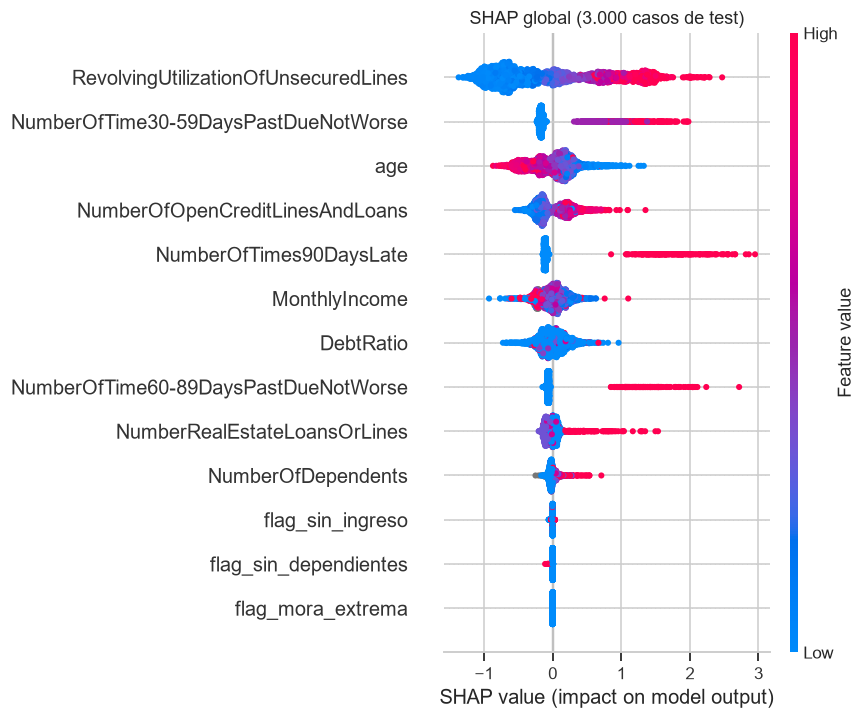

RevolvingUtilizationOfUnsecuredLines    0.712
NumberOfTime30-59DaysPastDueNotWorse    0.292
age                                     0.250
NumberOfOpenCreditLinesAndLoans         0.208
NumberOfTimes90DaysLate                 0.205
MonthlyIncome                           0.144
DebtRatio                               0.143
NumberOfTime60-89DaysPastDueNotWorse    0.136
NumberRealEstateLoansOrLines            0.082
NumberOfDependents                      0.043
flag_sin_ingreso                        0.003
flag_sin_dependientes                   0.002
flag_mora_extrema                       0.000
dtype: float64

In [144]:
import shap

explicador_shap = shap.TreeExplainer(modelo_dev)
muestra_test = X_test.sample(3000, random_state=SEED)
sv = explicador_shap(muestra_test)

shap.plots.beeswarm(sv, max_display=13, show=False)
plt.title("SHAP global (3.000 casos de test)")
plt.tight_layout(); plt.show()

importancia = pd.Series(np.abs(sv.values).mean(0), index=muestra_test.columns).sort_values(ascending=False)
importancia.round(3)

**Lectura global.** `RevolvingUtilization` domina con el triple de peso que la siguiente
(0,71 de |SHAP| medio): este modelo es, ante todo, un detector de tarjetas al límite. Le siguen
los retrasos de 30-59 días, la edad, el número de líneas abiertas y los retrasos de 90 días.
Nótese que `flag_mora_extrema` tiene importancia global ≈ 0 **sin ser inútil**: afecta a solo
~0,2% de los casos (por eso su media es invisible) pero para esos clientes es decisivo, la
importancia global media es ciega a las variables raras-pero-críticas, primera advertencia
metodológica de la sección. Y la edad, tercera variable del modelo, es legalmente un atributo
protegido: lo cuantificamos en §9.3.

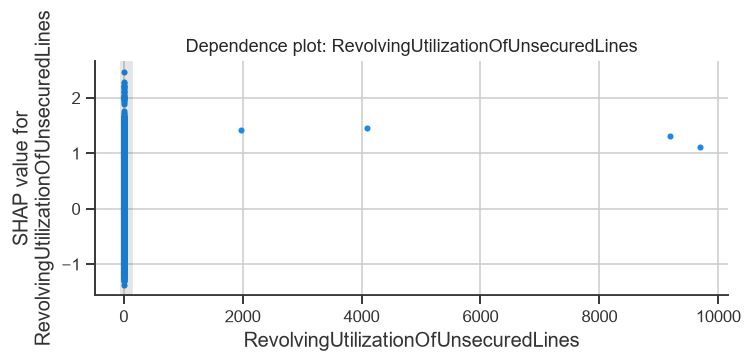

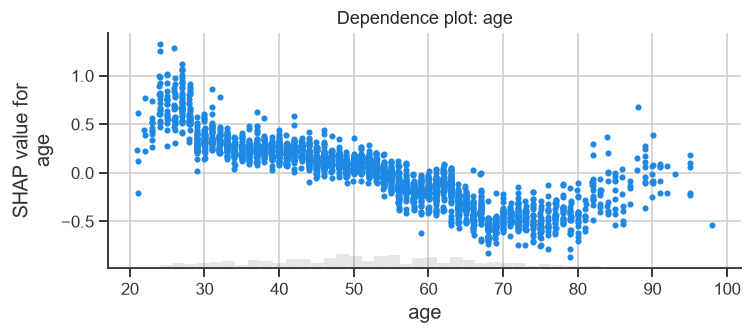

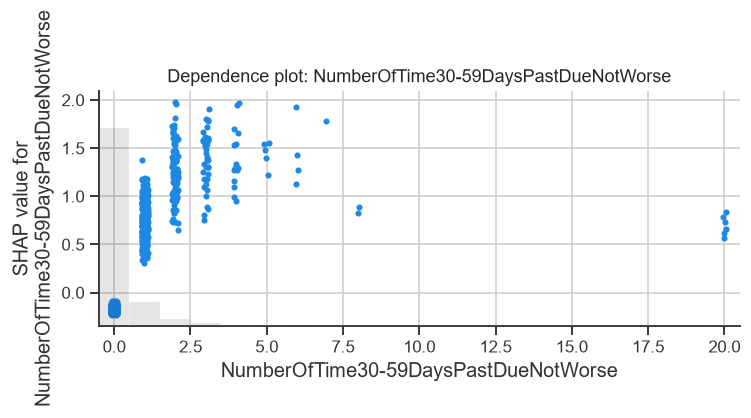

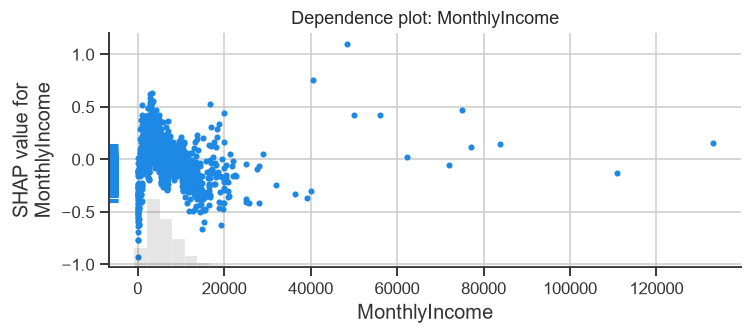

In [145]:
fig_vars = ["RevolvingUtilizationOfUnsecuredLines", "age",
            "NumberOfTime30-59DaysPastDueNotWorse", "MonthlyIncome"]
for v in fig_vars:
    shap.plots.scatter(sv[:, v], show=False)
    plt.gcf().set_size_inches(7, 3.2)
    plt.title(f"Dependence plot: {v}")
    plt.tight_layout(); plt.show()

**Lectura de los efectos.** (1) La utilización castiga de forma casi logística hasta
saturar cerca de 1, y la zona >1 (rebasar el límite) ya no añade castigo, coherente con los
errores de unidad de §2.5. (2) La edad protege monótonamente: a igualdad de todo lo demás, un
solicitante de 30 años carga ~0,4 log-odds más que uno de 65, el origen exacto de la
disparidad que mediremos en §9.3. (3) Un solo retraso de 30-59 días dispara el score (el salto
0→1 es el mayor del gráfico); los siguientes añaden cada vez menos. (4) `MonthlyIncome` es la
más interesante para la auditoría: su efecto **no es monótono**, el riesgo baja con los
ingresos hasta ~10-12.000, pero en la cola alta vuelve a subir ligeramente. Esto explica los
contrafactuales perversos de §8 ("gane usted menos") y confirma que el modelo ha memorizado
una correlación local sin sentido causal.

### 9.2 Permutation Feature Importance por coste

Permutation Feature Importance mide cuánto empeora el modelo cuando destruimos la información de
una variable, permutándola entre clientes. A diferencia de SHAP, que responde “qué variables mueven
las predicciones”, esta técnica responde “qué variables son necesarias para mantener bajo el coste”.

Como la evaluación de la práctica depende del **coste medio** en dos matrices distintas, calculamos
la importancia dos veces: una con la política del escenario 1 (`FP=FN=1`) y otra con la política del
escenario 2 (`FP=1, FN=10`). En ambos casos mantenemos fijo el modelo y el umbral ya elegido; solo
rompemos una columna del test y medimos cuánto sube el coste.


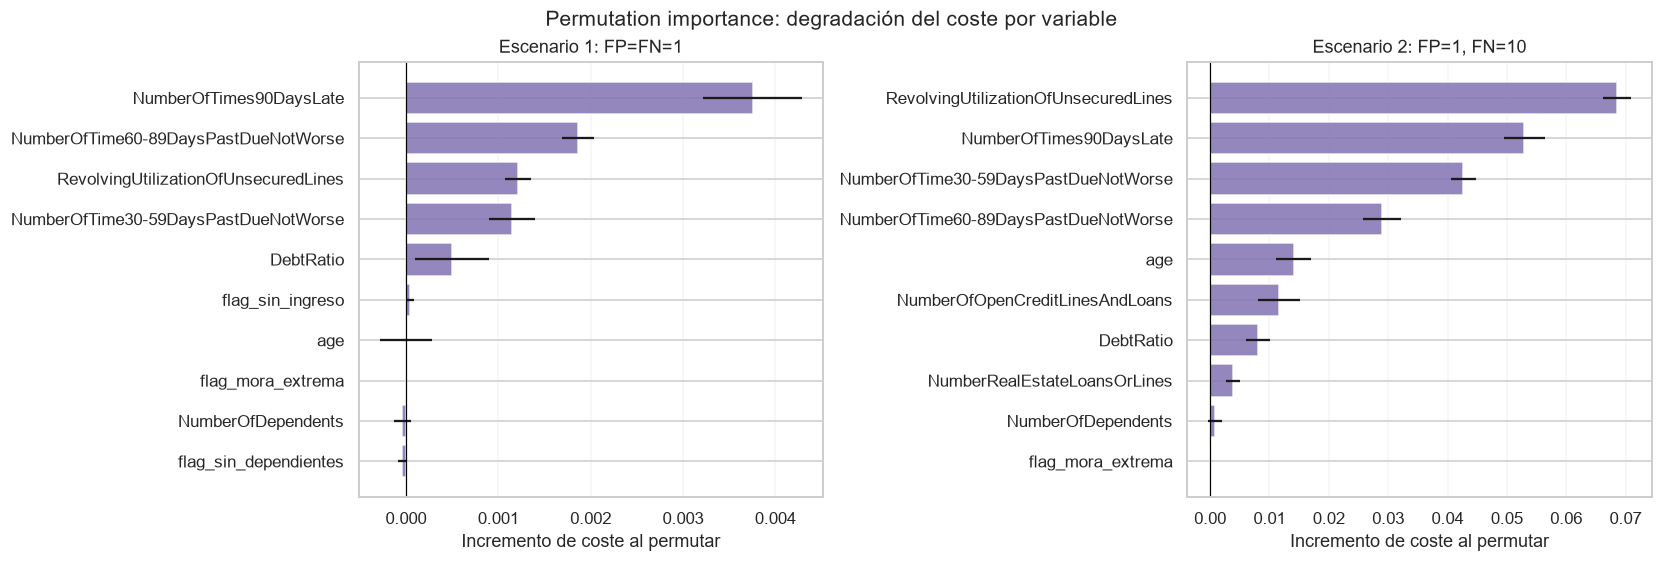

Coste base usado para comparar:


,coste_base
escenario,
E1 (FP=FN=1),0.0635
"E2 (FP=1, FN=10)",0.3351


Permutation importance por coste, ordenada por escenario 2:


,delta_coste_E1_media,delta_coste_E1_std,delta_coste_E2_media,delta_coste_E2_std
variable,,,,
RevolvingUtilizationOfUnsecuredLines,0.00121,0.00014,0.06853,0.00234
NumberOfTimes90DaysLate,0.00375,0.00053,0.05296,0.00340
NumberOfTime30-59DaysPastDueNotWorse,0.00115,0.00025,0.04265,0.00212
NumberOfTime60-89DaysPastDueNotWorse,0.00186,0.00017,0.02901,0.00323
age,0.00000,0.00029,0.01407,0.00301
NumberOfOpenCreditLinesAndLoans,-0.00027,0.00029,0.01157,0.00350
DebtRatio,0.00050,0.00040,0.00807,0.00198
NumberRealEstateLoansOrLines,-0.00027,0.00008,0.00390,0.00121
NumberOfDependents,-0.00004,0.00009,0.00088,0.00118


In [146]:
# Permutation Feature Importance usando el coste de negocio como métrica
rng_perm = np.random.default_rng(SEED)
N_REPEATS_PERM = 5

base_perm = pd.DataFrame({
    "escenario": ["E1 (FP=FN=1)", "E2 (FP=1, FN=10)"],
    "coste_base": [
        coste_medio(y_test, (proba_test > t1_dev).astype(int), C_FP_1, C_FN_1),
        coste_medio(y_test, (proba_test > t2_dev).astype(int), C_FP_2, C_FN_2),
    ],
}).set_index("escenario")

filas_perm = []
for variable in X_test.columns:
    incrementos_e1 = []
    incrementos_e2 = []
    for _ in range(N_REPEATS_PERM):
        X_perm = X_test.copy()
        X_perm[variable] = rng_perm.permutation(X_perm[variable].to_numpy())
        p_perm = modelo_dev.predict_proba(X_perm)[:, 1]
        coste_e1_perm = coste_medio(y_test, (p_perm > t1_dev).astype(int), C_FP_1, C_FN_1)
        coste_e2_perm = coste_medio(y_test, (p_perm > t2_dev).astype(int), C_FP_2, C_FN_2)
        incrementos_e1.append(coste_e1_perm - base_perm.loc["E1 (FP=FN=1)", "coste_base"])
        incrementos_e2.append(coste_e2_perm - base_perm.loc["E2 (FP=1, FN=10)", "coste_base"])
    filas_perm.append({
        "variable": variable,
        "delta_coste_E1_media": np.mean(incrementos_e1),
        "delta_coste_E1_std": np.std(incrementos_e1),
        "delta_coste_E2_media": np.mean(incrementos_e2),
        "delta_coste_E2_std": np.std(incrementos_e2),
    })

perm_coste = pd.DataFrame(filas_perm).set_index("variable")
perm_coste = perm_coste.sort_values("delta_coste_E2_media", ascending=False)

top_perm = perm_coste.head(10)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

for ax, col, err_col, titulo in [
    (axes[0], "delta_coste_E1_media", "delta_coste_E1_std", "Escenario 1: FP=FN=1"),
    (axes[1], "delta_coste_E2_media", "delta_coste_E2_std", "Escenario 2: FP=1, FN=10"),
]:
    orden = perm_coste.sort_values(col, ascending=True).tail(10)
    ax.barh(orden.index, orden[col], xerr=orden[err_col], color="#8172B2", alpha=0.85)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(titulo)
    ax.set_xlabel("Incremento de coste al permutar")
    ax.grid(axis="x", alpha=0.2)

fig.suptitle("Permutation importance: degradación del coste por variable", fontsize=14)
plt.show()

print("Coste base usado para comparar:")
display(base_perm.round(4))

print("Permutation importance por coste, ordenada por escenario 2:")
display(perm_coste.round(5))


**Lectura de permutation importance.** Una variable se considera importante si, al permutar sus valores entre clientes, aumenta el
coste de negocio. Esta técnica mide cuánto empeora el modelo cuando se destruye la información útil que aporta esa variable. Complementa a SHAP porque una variable puede tener un impacto alto en las probabilidades predichas y, aun así, modificar pocas
decisiones si esas probabilidades están lejos del umbral; o puede afectar a pocos clientes, pero generar un coste elevado si cambia decisiones sobre morosos en el escenario 2.

Por eso calculamos la importancia separada para E1 y E2. En E2, los falsos negativos cuestan 10, así que las variables que ayudan a detectar morosos antes de conceder deberían ganar peso. Con esta información, relacionamos la explicabilidad global con el 50% de evaluación basado en coste, no solo con métricas genéricas como AUC.


### 9.3 PDP / ICE / ALE para variables clave

Añadimos PDP, ICE y ALE para analizar **qué forma funcional ha aprendido el modelo** en las
variables que más pesan en la auditoría. SHAP indica qué variables empujan una predicción hacia
arriba o hacia abajo, pero estas técnicas permiten estudiar con más detalle cómo cambia la
probabilidad estimada cuando varía una característica concreta.

- **PDP** (*Partial Dependence Plot*): muestra el efecto medio que tendría fijar una variable en
  distintos valores para todos los clientes. Sirve para identificar tendencias generales aprendidas
  por el modelo.

- **ICE** (*Individual Conditional Expectation*): repite el mismo análisis cliente a cliente.
  Aporta información sobre la heterogeneidad del efecto, es decir, permite ver si todos los clientes
  responden de forma parecida o si el promedio del PDP oculta comportamientos distintos.

- **ALE** (*Accumulated Local Effects*): estima efectos locales usando rangos de valores observados
  en los datos. Esto lo hace más prudente cuando una variable está correlacionada con otras, porque
  reduce la dependencia de combinaciones poco realistas de características.

Los gráficos describen cómo responde el modelo ante cambios
simulados en las variables, no qué ocurriría necesariamente en la realidad si un cliente modificara
su comportamiento. Por eso se utilizan como herramientas de auditoría del modelo y no como
recomendaciones automáticas para el cliente.

Variable excluida del mosaico PDP/ICE: MonthlyIncome (muchos nulos y cola extrema; no forzamos una imputación solo para dibujar)


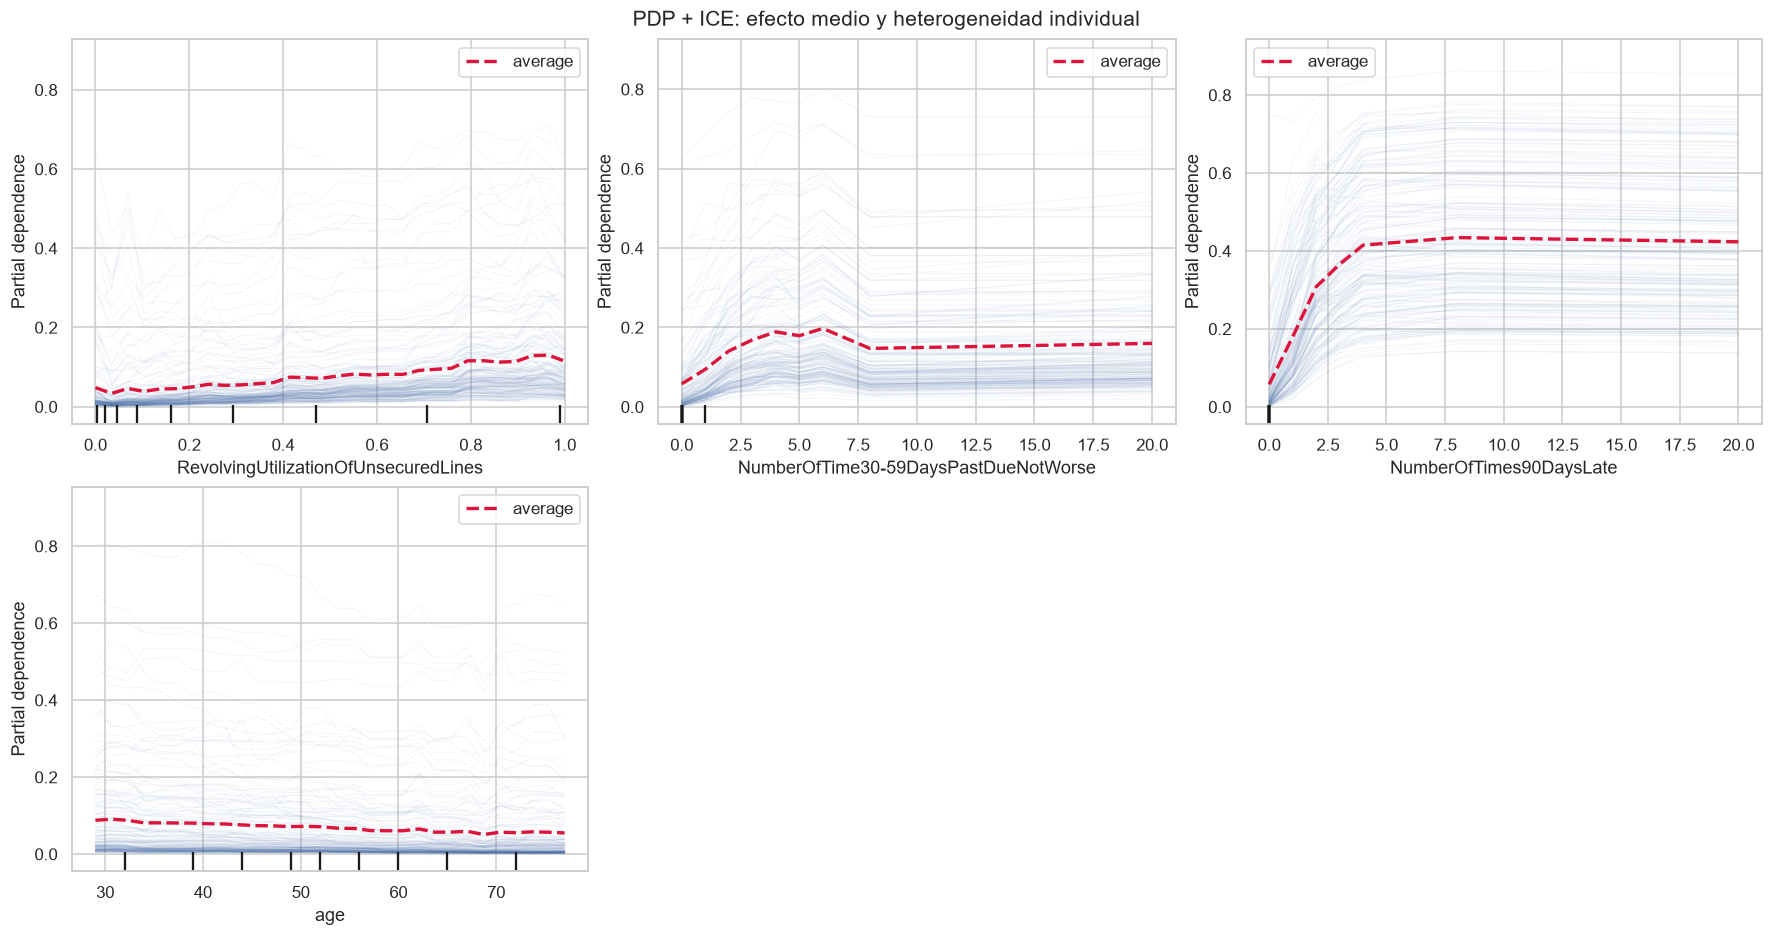

In [147]:
from sklearn.inspection import PartialDependenceDisplay

vars_pdp_ice = [
    "RevolvingUtilizationOfUnsecuredLines",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "age",
]
vars_excluidas_pdp_ice = ["MonthlyIncome"]  # muchos nulos + cola extrema: mejor no forzar PDP/ICE

# PDP + ICE sobre una muestra para mantener el notebook ágil y reproducible.
# kind='both' muestra el promedio (PDP) y curvas individuales (ICE) suavemente transparentes.
muestra_pdp = X_test.sample(min(1200, len(X_test)), random_state=SEED).copy().astype(float)

custom_values = {}
for v in ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate"]:
    valores = np.sort(X_dev[v].dropna().unique())
    valores = valores[valores <= np.nanpercentile(X_dev[v], 99)]
    custom_values[v] = valores.astype(float)

ncols = 3
nrows = int(np.ceil(len(vars_pdp_ice) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows), constrained_layout=True)
axes = np.ravel(axes)

for ax, v in zip(axes, vars_pdp_ice):
    PartialDependenceDisplay.from_estimator(
        modelo_dev, muestra_pdp, [v], kind="both", subsample=min(180, len(muestra_pdp)),
        grid_resolution=30, random_state=SEED, response_method="predict_proba",
        target=1, ax=ax, custom_values=custom_values,
        ice_lines_kw={"alpha": 0.06, "linewidth": 0.7},
        pd_line_kw={"color": "crimson", "linewidth": 2.2}
    )
    ax.set_title(f"PDP + ICE: {v}")
    ax.set_ylabel("p(mora) predicha")

for ax in axes[len(vars_pdp_ice):]:
    ax.axis("off")
fig.suptitle("PDP + ICE: efecto medio y heterogeneidad individual", fontsize=14)
print("Variable excluida del mosaico PDP/ICE:", ", ".join(vars_excluidas_pdp_ice),
      "(muchos nulos y cola extrema; no forzamos una imputación solo para dibujar)")
plt.show()


Variable excluida del mosaico ALE: NumberOfTimes90DaysLate (discreta y casi siempre 0; SHAP/dependence plot la explica mejor)


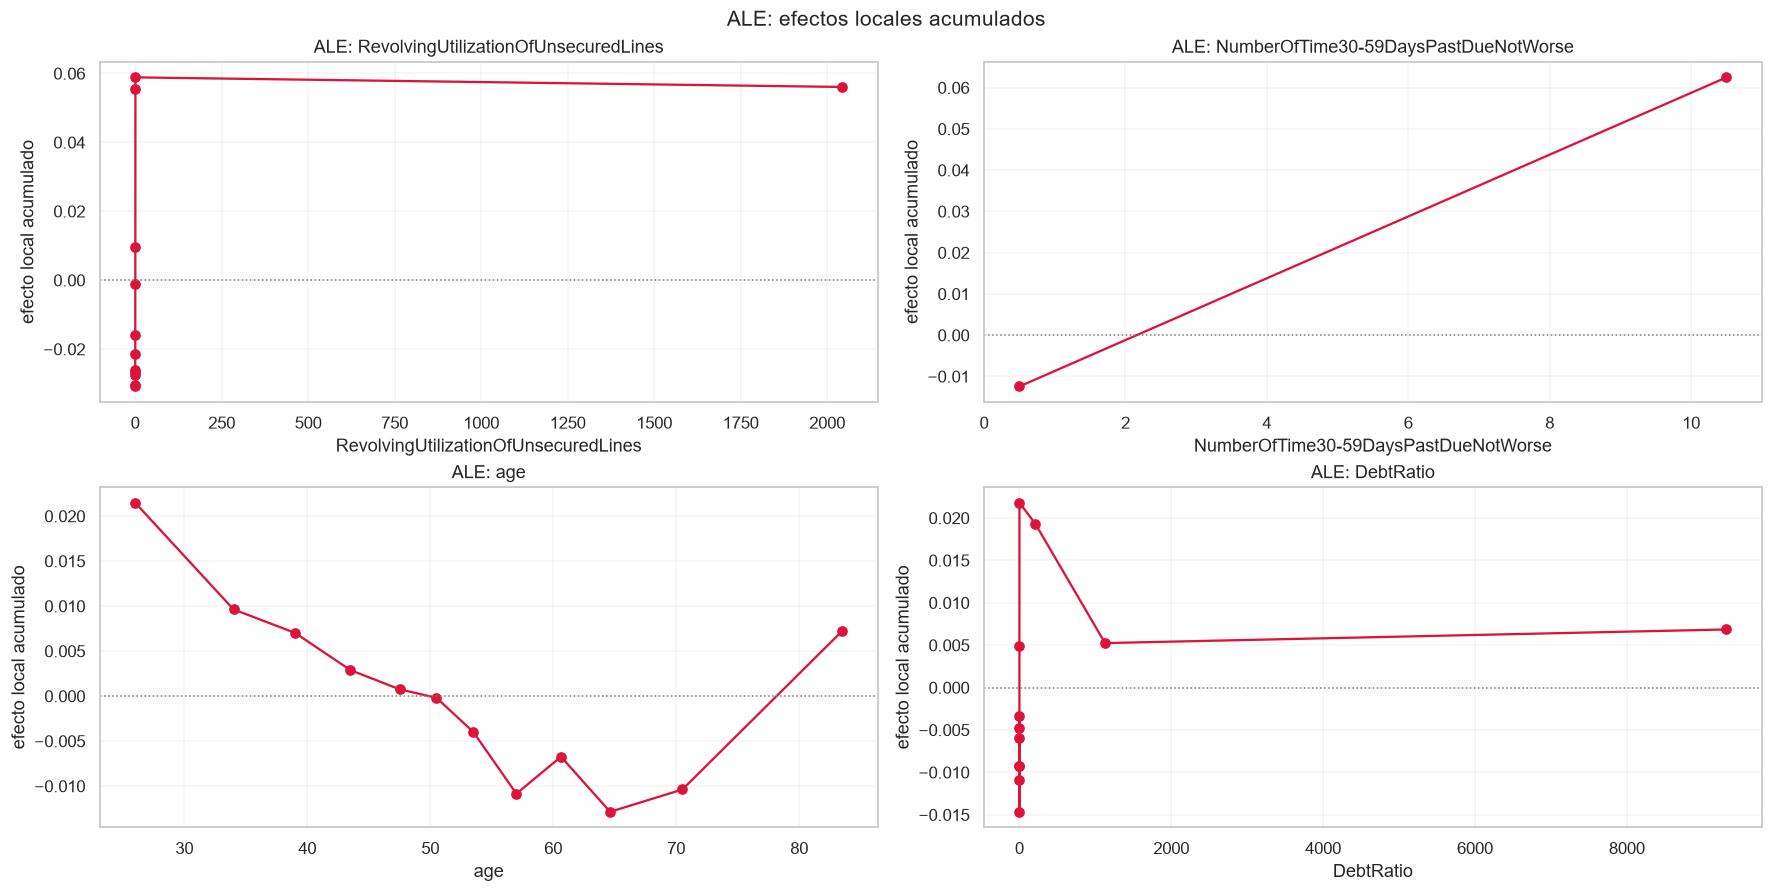

In [148]:
def calcula_ale_1d(modelo, X, variable, bins=12):
    """ALE de primer orden para clasificación binaria, centrado a media cero.

    En cada intervalo observado [z_k, z_{k+1}] mide cuánto cambia p(mora) al mover
    solo esa variable desde el borde inferior al superior, y acumula esos efectos locales.
    """
    x = X[variable].dropna()
    cortes = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(cortes) < 2:
        return pd.DataFrame(columns=["x", "ale", "n"])
    if len(cortes) < 3:
        # Variables discretas muy concentradas en cero colapsan los cuantiles.
        # En ese caso usamos sus valores observados hasta p99 como malla de cortes.
        maximo = x.quantile(0.99)
        cortes = np.sort(x[x <= maximo].unique())
    if len(cortes) < 2:
        return pd.DataFrame(columns=["x", "ale", "n"])

    cod = np.searchsorted(cortes, X[variable], side="right") - 1
    cod = np.clip(cod, 0, len(cortes) - 2)

    efectos = []
    conteos = []
    for k in range(len(cortes) - 1):
        m = (cod == k) & X[variable].notna().to_numpy()
        conteos.append(int(m.sum()))
        if not m.any():
            efectos.append(0.0)
            continue
        x_low = X.loc[m].copy()
        x_high = X.loc[m].copy()
        x_low[variable] = cortes[k]
        x_high[variable] = cortes[k + 1]
        delta = (modelo.predict_proba(x_high)[:, 1] -
                 modelo.predict_proba(x_low)[:, 1]).mean()
        efectos.append(float(delta))

    ale = np.cumsum(efectos)
    centros = 0.5 * (cortes[:-1] + cortes[1:])
    pesos = np.asarray(conteos, dtype=float)
    if pesos.sum() > 0:
        ale = ale - np.average(ale, weights=pesos)
    return pd.DataFrame({"x": centros, "ale": ale, "n": conteos})

vars_ale = [
    "RevolvingUtilizationOfUnsecuredLines",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "age",
    "DebtRatio",
]
vars_excluidas_ale = ["NumberOfTimes90DaysLate"]  # casi siempre 0: ALE por intervalos no es informativo

ncols = 2
nrows = int(np.ceil(len(vars_ale) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.0 * nrows), constrained_layout=True)
axes = np.ravel(axes)
for ax, v in zip(np.ravel(axes), vars_ale):
    ale_v = calcula_ale_1d(modelo_dev, muestra_pdp, v, bins=12)
    if ale_v.empty:
        ax.text(0.5, 0.5, "Sin variación suficiente\npara calcular ALE", ha="center", va="center")
    else:
        ax.plot(ale_v["x"], ale_v["ale"], marker="o", color="crimson")
    ax.axhline(0, color="gray", lw=1, ls=":")
    ax.set_title(f"ALE: {v}")
    ax.set_xlabel(v)
    ax.set_ylabel("efecto local acumulado")
    ax.grid(alpha=0.2)
for ax in axes[len(vars_ale):]:
    ax.axis("off")
fig.suptitle("ALE: efectos locales acumulados", fontsize=14)
print("Variable excluida del mosaico ALE:", ", ".join(vars_excluidas_ale),
      "(discreta y casi siempre 0; SHAP/dependence plot la explica mejor)")
plt.show()


**Lectura PDP/ICE/ALE.** La utilización de crédito y los retrasos pasados muestran el patrón más
coherente para negocio: al aumentar, la probabilidad de impago sube y después se satura. Las curvas
ICE enseñan que no todos los clientes reaccionan igual: cerca del umbral hay perfiles donde un
cambio pequeño en utilización o retrasos altera mucho la decisión, mientras que en perfiles ya muy
seguros el efecto marginal es menor. ALE confirma la misma dirección sin depender tanto de
combinaciones artificiales de variables; por eso es una buena comprobación cuando edad, ingresos,
deuda y líneas abiertas están correlacionadas.

Dos detalles técnicos explican las exclusiones. No hacemos PDP/ICE de `MonthlyIncome` porque tiene
muchos nulos y una cola extrema: forzar una rejilla exigiría imputar o recortar solo para dibujar,
y eso mezclaría la explicación del modelo con una decisión artificial de visualización. Tampoco
hacemos ALE de `NumberOfTimes90DaysLate`: es una variable discreta y casi siempre vale 0, así que
los intervalos de ALE se colapsan y el gráfico deja de ser informativo. Para esas dos variables nos
quedamos con SHAP/dependence plots y con el análisis de nulos/calidad de datos de la sección 2.

La edad y los ingresos requieren más cautela: si el modelo aprende que ciertos rangos reducen el
riesgo, eso no significa que recomendar “cumplir años” o “declarar más ingresos” sea una
explicación accionable. Para clientes, la información útil debe centrarse en variables modificables
y verificables, sobre todo utilización y ausencia de retrasos recientes.


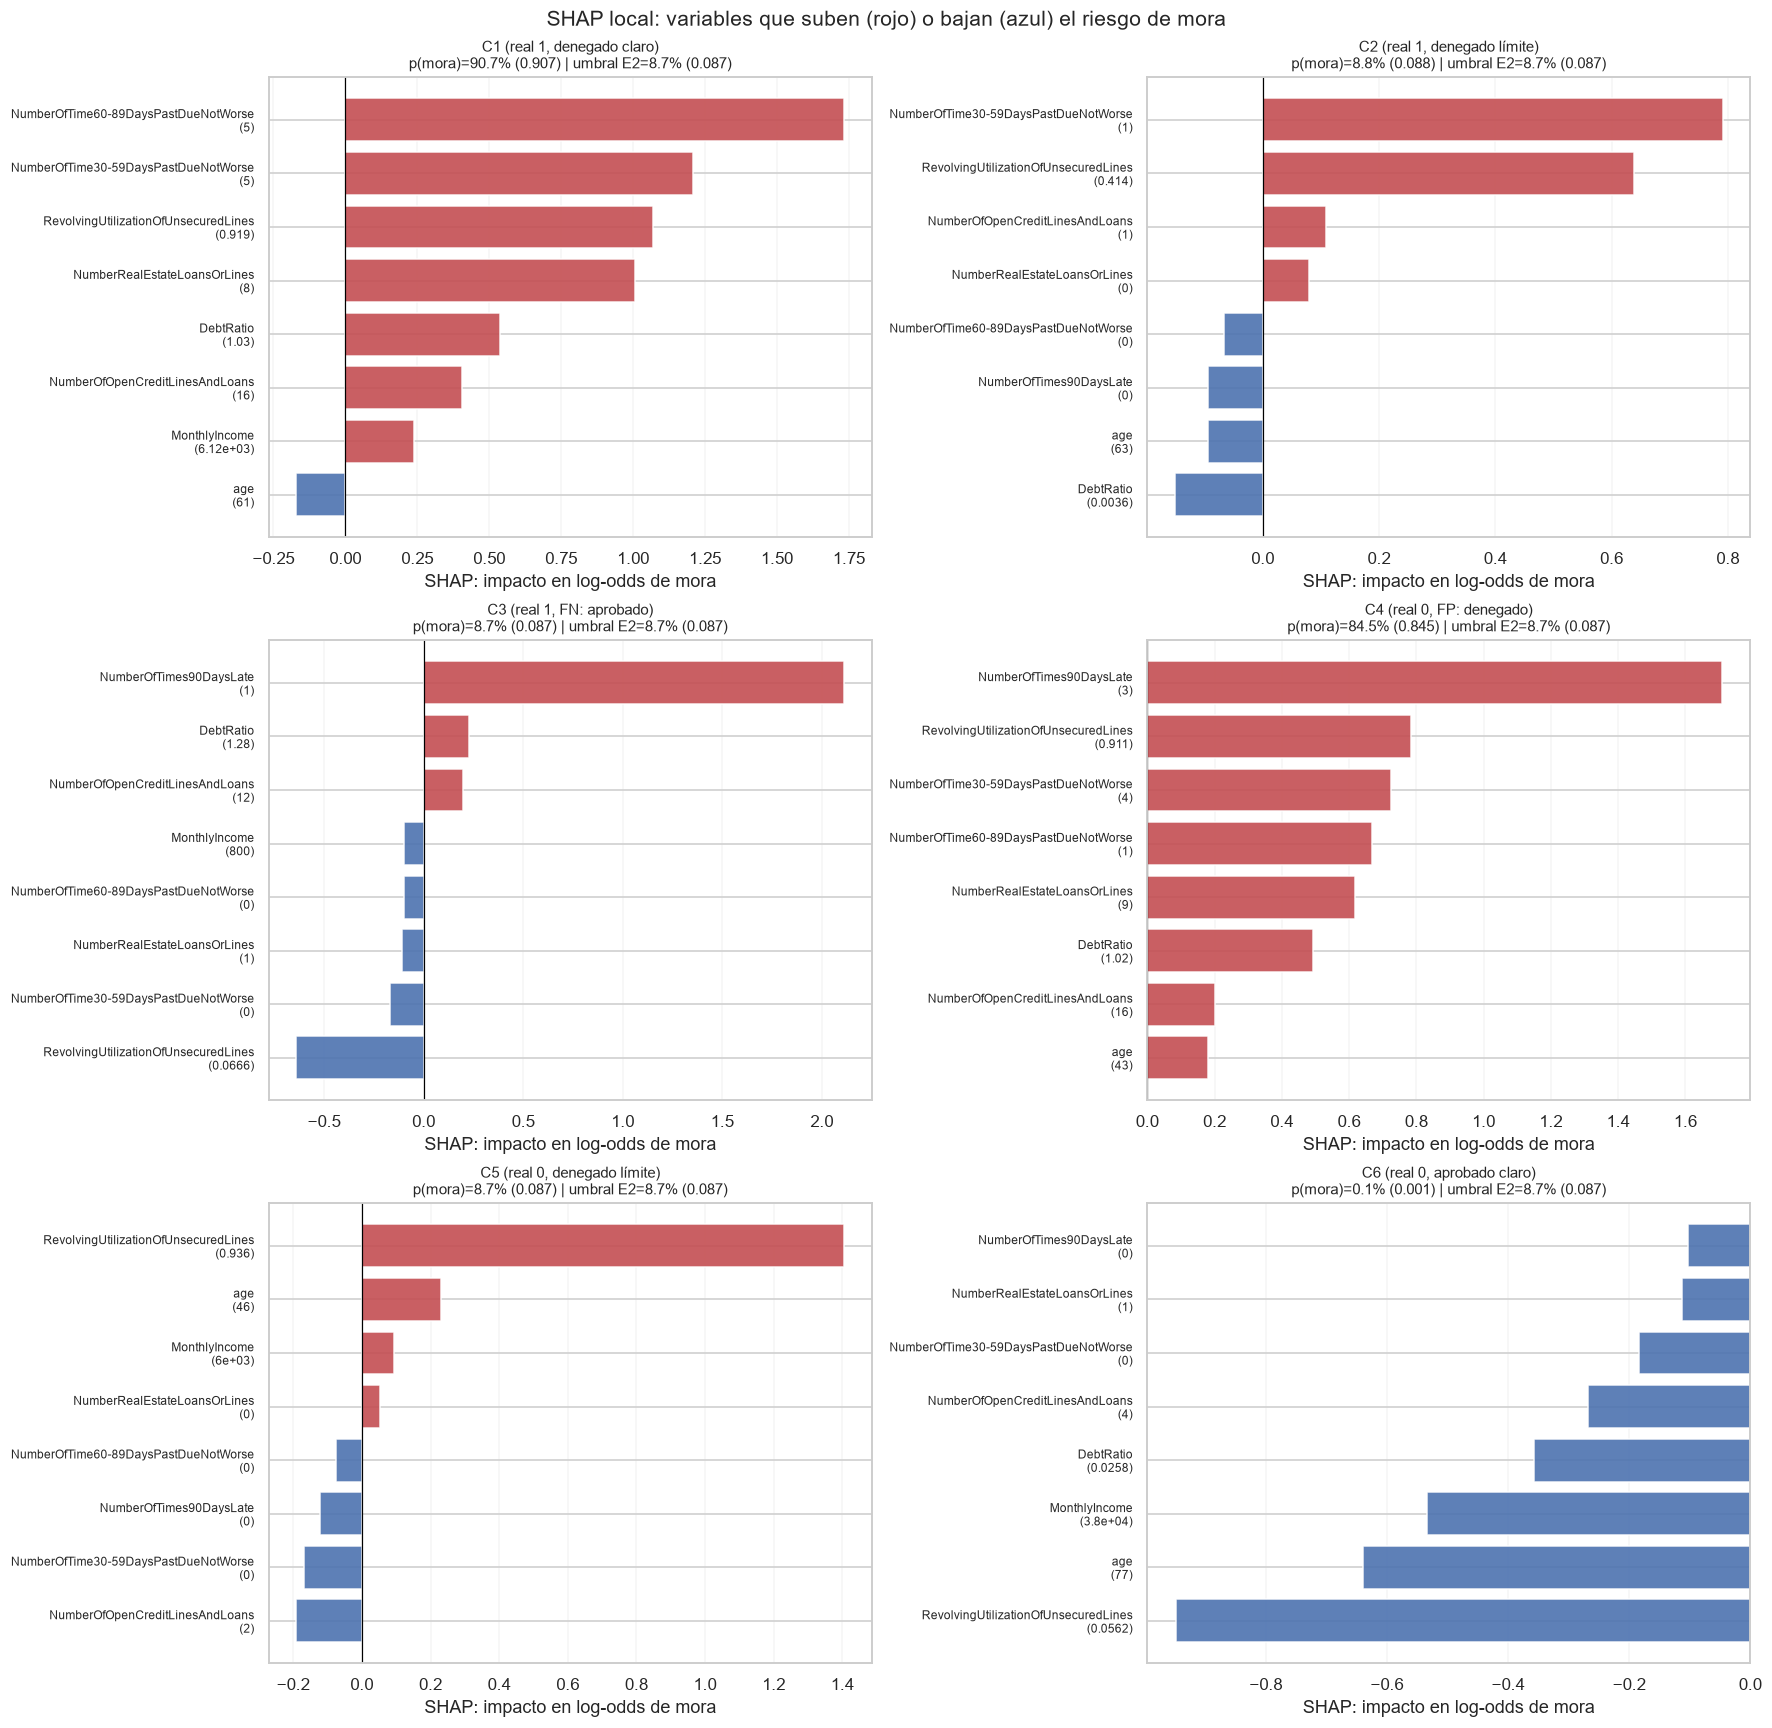

In [149]:
# Explicación local de los 6 clientes de la sección 8
X_clientes = X_test.loc[list(clientes.values())]
sv_clientes = explicador_shap(X_clientes)

ncols = 2
nrows = int(np.ceil(len(clientes) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5.2 * nrows), constrained_layout=True)
axes = np.ravel(axes)

for ax, (i, nombre) in zip(axes, enumerate(clientes)):
    valores = pd.Series(sv_clientes.values[i], index=X_clientes.columns)
    top = valores.reindex(valores.abs().nlargest(8).index).sort_values()
    colores = np.where(top > 0, "#C44E52", "#4C72B0")
    etiquetas = [f"{v}\n({X_clientes.iloc[i][v]:.3g})" for v in top.index]

    ax.barh(range(len(top)), top.values, color=colores, alpha=0.9)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(etiquetas, fontsize=8)
    ax.axvline(0, color="black", lw=0.8)
    ax.grid(axis="x", alpha=0.2)
    p_i = modelo_dev.predict_proba(X_clientes.iloc[[i]])[:, 1][0]
    ax.set_title(
        f"{nombre}\np(mora)={p_i:.1%} ({p_i:.3f}) | umbral E2={t2_dev:.1%} ({t2_dev:.3f})",
        fontsize=10
    )
    ax.set_xlabel("SHAP: impacto en log-odds de mora")

for ax in axes[len(clientes):]:
    ax.axis("off")

fig.suptitle("SHAP local: variables que suben (rojo) o bajan (azul) el riesgo de mora", fontsize=14)
plt.show()


**Lectura de las explicaciones locales.** Estas gráficas muestran, para los mismos seis clientes analizados en los contrafactuales de §8, qué variables empujan la predicción individual hacia una mayor o menor probabilidad de impago. Las barras rojas aumentan el riesgo estimado por el modelo y las azules lo reducen; la longitud de cada barra indica la intensidad de esa contribución en la escala de log-odds.

El objetivo no es repetir la decisión final, sino entender su composición. En los clientes denegados con alta confianza, las contribuciones suelen concentrarse en variables de utilización del crédito y retrasos previos, lo que confirma que el modelo está apoyando la denegación en señales de riesgo financiero directamente relacionadas con el historial de pago. En los casos cercanos al umbral, las barras aparecen más repartidas y con magnitudes menores, reflejando decisiones más frágiles: pequeñas variaciones en una o dos variables pueden cambiar la concesión.

Este análisis complementa a los contrafactuales. SHAP explica qué variables han pesado en la predicción observada, mientras que los contrafactuales indican qué cambios plausibles habrían cruzado el umbral de aprobación. Cuando ambas lecturas coinciden, la explicación local gana consistencia; cuando divergen, la diferencia ayuda a distinguir entre variables explicativas y variables realmente accionables para el cliente.


### 9.4 LIME local para los mismos 6 clientes

LIME (*Local Interpretable Model-Agnostic Explanations*) aproxima el modelo caja negra alrededor de
un cliente concreto con un modelo lineal local y sencillo. Lo usamos sobre los **mismos 6 clientes**
de contrafactuales y SHAP para comprobar si otra técnica local cuenta una historia parecida.

Para no inventar datos ni imputar solo para visualizar, el explicador se ajusta con filas completas
de desarrollo (`X_dev.dropna()`). Los seis clientes seleccionados en §8 también son casos completos,
así que LIME explica los valores realmente observados. La limitación queda clara: LIME genera
perturbaciones locales sintéticas alrededor del cliente; por eso lo tratamos como contraste de SHAP,
no como verdad regulatoria aislada.


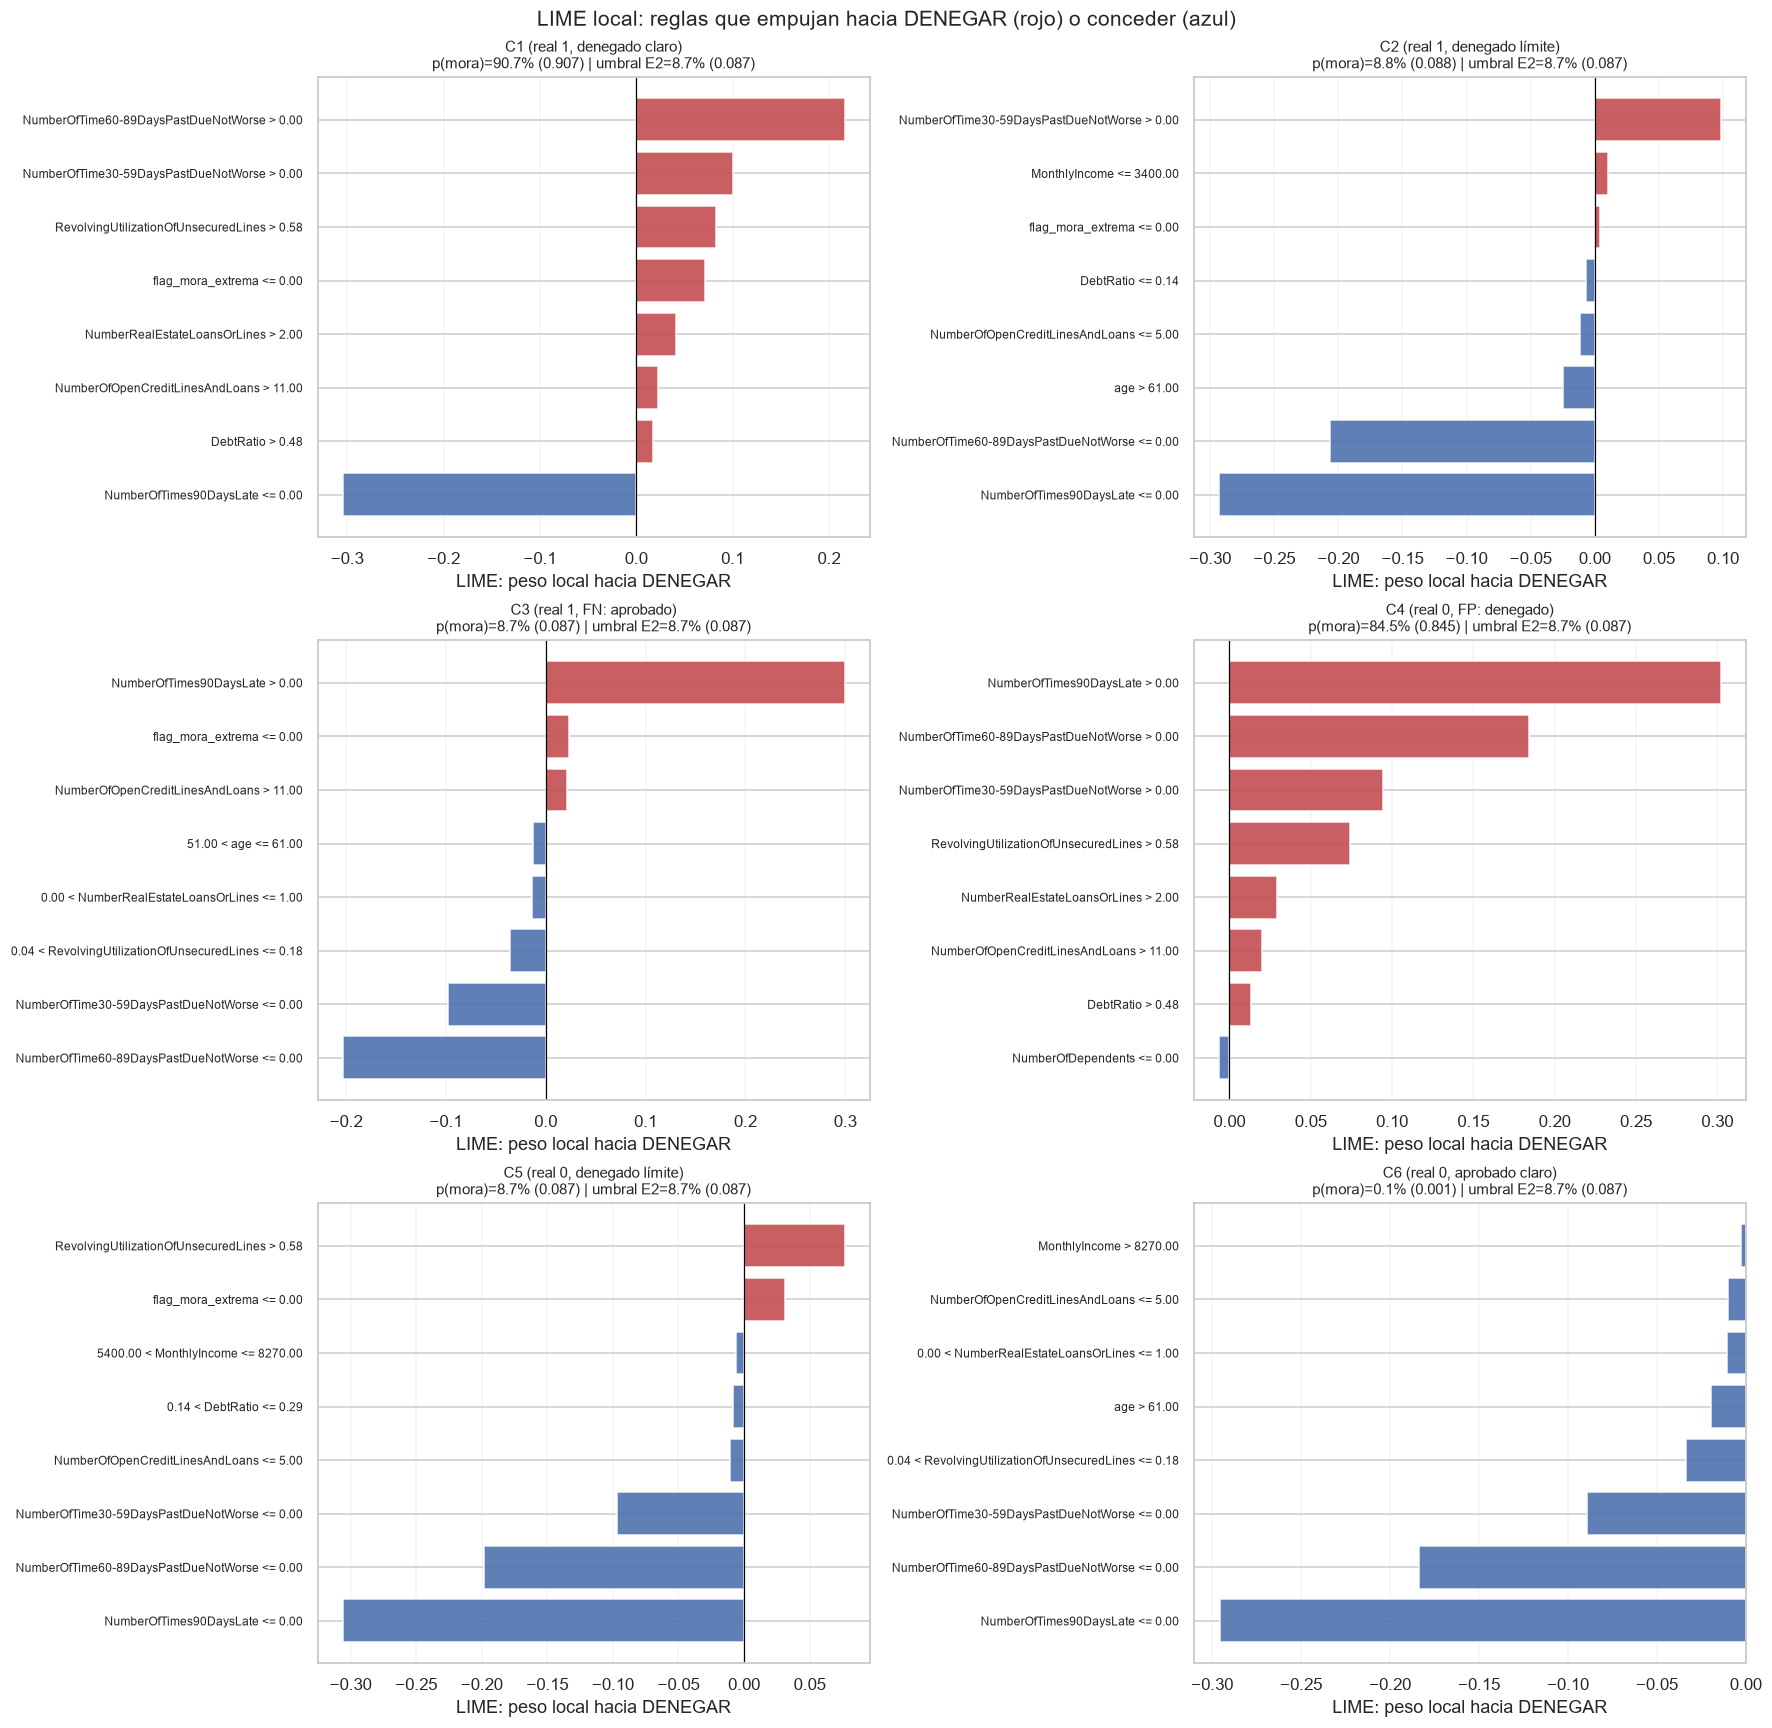

,top reglas LIME,score local LIME,p_mora
cliente,,,
"C1 (real 1, denegado claro)",NumberOfTimes90DaysLate <= 0.00 | NumberOfTime60-89DaysPastDueNotWorse > 0.00 | NumberOfTime30-59DaysPastDueNotWorse > 0.00,0.727,0.907485
"C2 (real 1, denegado límite)",NumberOfTimes90DaysLate <= 0.00 | NumberOfTime60-89DaysPastDueNotWorse <= 0.00 | NumberOfTime30-59DaysPastDueNotWorse > 0.00,0.597,0.087687
"C3 (real 1, FN: aprobado)",NumberOfTimes90DaysLate > 0.00 | NumberOfTime60-89DaysPastDueNotWorse <= 0.00 | NumberOfTime30-59DaysPastDueNotWorse <= 0.00,0.643,0.086855
"C4 (real 0, FP: denegado)",NumberOfTimes90DaysLate > 0.00 | NumberOfTime60-89DaysPastDueNotWorse > 0.00 | NumberOfTime30-59DaysPastDueNotWorse > 0.00,0.735,0.845189
"C5 (real 0, denegado límite)",NumberOfTimes90DaysLate <= 0.00 | NumberOfTime60-89DaysPastDueNotWorse <= 0.00 | NumberOfTime30-59DaysPastDueNotWorse <= 0.00,0.693,0.087006
"C6 (real 0, aprobado claro)",NumberOfTimes90DaysLate <= 0.00 | NumberOfTime60-89DaysPastDueNotWorse <= 0.00 | NumberOfTime30-59DaysPastDueNotWorse <= 0.00,0.621,0.001051


In [150]:
from lime.lime_tabular import LimeTabularExplainer

X_lime_bg = X_dev.dropna().astype(float)
assert not X_clientes.isna().any().any(), "Los clientes elegidos para LIME deben tener datos completos"

expl_lime = LimeTabularExplainer(
    training_data=X_lime_bg.to_numpy(),
    feature_names=list(X_dev.columns),
    class_names=["conceder", "DENEGAR"],
    mode="classification",
    discretize_continuous=True,
    random_state=SEED,
)

def predict_lime(z):
    return modelo_dev.predict_proba(pd.DataFrame(z, columns=X_dev.columns))

lime_exps = {}
lime_resumen = []

ncols = 2
nrows = int(np.ceil(len(clientes) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5.2 * nrows), constrained_layout=True)
axes = np.ravel(axes)

for ax, (i, nombre) in zip(axes, enumerate(clientes)):
    x_i = X_clientes.iloc[i].astype(float)
    exp = expl_lime.explain_instance(
        data_row=x_i.to_numpy(),
        predict_fn=predict_lime,
        labels=(1,),
        num_features=8,
        num_samples=3000,
    )
    pares = exp.as_list(label=1)
    lime_exps[nombre] = exp

    tabla = pd.DataFrame(pares, columns=["regla_local", "peso_lime"])
    tabla = tabla.sort_values("peso_lime")
    colores = np.where(tabla["peso_lime"] > 0, "#C44E52", "#4C72B0")

    ax.barh(range(len(tabla)), tabla["peso_lime"], color=colores, alpha=0.9)
    ax.set_yticks(range(len(tabla)))
    ax.set_yticklabels(tabla["regla_local"], fontsize=8)
    ax.axvline(0, color="black", lw=0.8)
    ax.grid(axis="x", alpha=0.2)
    p_i = modelo_dev.predict_proba(X_clientes.iloc[[i]])[:, 1][0]
    ax.set_title(
        f"{nombre}\np(mora)={p_i:.1%} ({p_i:.3f}) | umbral E2={t2_dev:.1%} ({t2_dev:.3f})",
        fontsize=10,
    )
    ax.set_xlabel("LIME: peso local hacia DENEGAR")

    top_vars_lime = [r.split(" <= ")[0].split(" > ")[0].split(" < ")[0] for r, _ in pares[:3]]
    lime_resumen.append({
        "cliente": nombre,
        "top reglas LIME": " | ".join(r for r, _ in pares[:3]),
        "score local LIME": round(float(exp.score), 3),
        "p_mora": p_i,
    })

for ax in axes[len(clientes):]:
    ax.axis("off")

fig.suptitle("LIME local: reglas que empujan hacia DENEGAR (rojo) o conceder (azul)", fontsize=14)
plt.show()

lime_resumen = pd.DataFrame(lime_resumen).set_index("cliente")
lime_resumen


**Lectura LIME.** LIME debería leerse como un tercer punto de vista local: SHAP reparte la
predicción entre variables del modelo, los contrafactuales buscan cambios mínimos que cruzan el
umbral y LIME aproxima la frontera alrededor de cada cliente con reglas simples. Cuando LIME vuelve
a destacar utilización y retrasos, aumenta la confianza en que la explicación es estable. Si LIME
prioriza reglas distintas en clientes frontera, no es necesariamente un error: cerca del umbral la
frontera local es inestable y pequeñas perturbaciones pueden cambiar qué regla parece dominante.

El `score local LIME` resume cuánto se parece el modelo lineal local de LIME a la caja negra en las
perturbaciones generadas alrededor del cliente. Si es bajo, esa explicación local debe tratarse con
más cautela y apoyarse en SHAP/contrafactuales.


In [151]:
# Cruce contrafactual ↔ SHAP: ¿coinciden en qué variables importan para cada cliente?
cruce = []
for i, nombre in enumerate(clientes):
    shap_top = pd.Series(np.abs(sv_clientes.values[i]), index=X_clientes.columns).nlargest(3)
    vars_cf = set()
    if nombre in resultados_cf:
        for cf in resultados_cf[nombre]:
            vars_cf |= set(cf["cambios"])
    if nombre in dice_cf and dice_cf[nombre] is not None:
        x0 = X_clientes.iloc[i]
        for _, fila_cf in dice_cf[nombre].iterrows():
            vars_cf |= {c for c in ACCIONABLES if not np.isclose(x0[c], fila_cf[c], atol=1e-4)}
    top3 = list(shap_top.index)
    accionables_top = [v for v in top3 if v in ACCIONABLES]
    cruce.append({"cliente": nombre,
                  "top-3 |SHAP|": ", ".join(top3),
                  "variables en los CF": ", ".join(sorted(vars_cf)) if vars_cf else "—",
                  "coinciden": ("sí" if any(v in vars_cf for v in accionables_top)
                                else ("n/a" if not vars_cf else "no"))})
pd.options.display.max_colwidth = 120
pd.DataFrame(cruce).set_index("cliente")

,top-3 |SHAP|,variables en los CF,coinciden
cliente,,,
"C1 (real 1, denegado claro)","NumberOfTime60-89DaysPastDueNotWorse, NumberOfTime30-59DaysPastDueNotWorse, RevolvingUtilizationOfUnsecuredLines","DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89Da...",sí
"C2 (real 1, denegado límite)","NumberOfTime30-59DaysPastDueNotWorse, RevolvingUtilizationOfUnsecuredLines, DebtRatio","DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberRealEstateLoansOrLines, RevolvingUtilizationOfUnsec...",sí
"C3 (real 1, FN: aprobado)","NumberOfTimes90DaysLate, RevolvingUtilizationOfUnsecuredLines, DebtRatio","DebtRatio, MonthlyIncome, RevolvingUtilizationOfUnsecuredLines",sí
"C4 (real 0, FP: denegado)","NumberOfTimes90DaysLate, RevolvingUtilizationOfUnsecuredLines, NumberOfTime30-59DaysPastDueNotWorse","DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89Da...",sí
"C5 (real 0, denegado límite)","RevolvingUtilizationOfUnsecuredLines, age, NumberOfOpenCreditLinesAndLoans","DebtRatio, MonthlyIncome, RevolvingUtilizationOfUnsecuredLines",sí
"C6 (real 0, aprobado claro)","RevolvingUtilizationOfUnsecuredLines, age, MonthlyIncome","DebtRatio, NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate, RevolvingUtilizationOfUnsecuredLines",sí


**Cruce CF ↔ SHAP.** Para los casos claros (C1, C4, C5) hay pleno acuerdo: las variables con
mayor |SHAP| local son exactamente las que los contrafactuales tocan (utilización y retrasos).
El acuerdo se degrada donde debe: en los clientes-frontera (C2, C3), SHAP reparte contribuciones
pequeñas entre muchas variables y los CF encuentran rutas dispares, coherente con la
inestabilidad de frontera vista en §8. La divergencia sistemática es instructiva: SHAP incluye
`age` en el top-3 de la mitad de los clientes, pero **ningún contrafactual puede tocarla**, la
variable que más explica no siempre es accionable, y una carta al cliente basada solo en SHAP
("su edad pesa en su contra") sería tan verdadera como inútil y probablemente ilegal.

### 9.5 Equidad por edad (análisis extra)

El modelo usa `age` directamente (tercera variable por importancia y con dirección clara:
ser joven penaliza). En la UE la edad es un atributo protegido en el acceso al crédito y el
credit scoring es un caso de uso de **alto riesgo** en el EU AI Act. Medimos el impacto de la
política del escenario 2 por tramos de edad, y cuantificamos qué costaría mitigarlo.

In [152]:
bandas_edad = pd.cut(X_test["age"], [20, 30, 45, 60, 110], labels=["21-30", "31-45", "46-60", "61+"])

def metricas_por_banda(pred):
    tabla = pd.DataFrame({"banda": bandas_edad, "y": y_test.values, "pred": np.asarray(pred, dtype=int)})
    return tabla.groupby("banda", observed=True).apply(
        lambda d: pd.Series({
            "n": len(d),
            "mora_real": d.y.mean(),
            "denegación": d.pred.mean(),
            "FPR (buenos denegados)": ((d.pred == 1) & (d.y == 0)).sum() / max((d.y == 0).sum(), 1),
            "FNR (morosos aprobados)": ((d.pred == 0) & (d.y == 1)).sum() / max((d.y == 1).sum(), 1)}),
        include_groups=False)

equidad_con_edad = metricas_por_banda(pred2_test)
print("Política escenario 2, modelo CON edad:")
equidad_con_edad.round(3)

Política escenario 2, modelo CON edad:


,n,mora_real,denegación,FPR (buenos denegados),FNR (morosos aprobados)
banda,,,,,
21-30,1556.0,0.102,0.379,0.328,0.170
31-45,5655.0,0.091,0.277,0.226,0.213
46-60,7556.0,0.073,0.177,0.140,0.346
61+,6167.0,0.029,0.072,0.058,0.449


In [153]:
# ¿Y si quitamos la edad? Coste de la mitigación + nueva disparidad
oof_sin_edad = cross_val_predict(crea_lgbm(), X_dev.drop(columns="age"), y_dev,
                                 cv=cv, method="predict_proba")[:, 1]
t2_sin_edad, c2_oof_sin_edad = umbral_optimo(y_dev, oof_sin_edad, C_FP_2, C_FN_2)
modelo_sin_edad = crea_lgbm().fit(X_dev.drop(columns="age"), y_dev)
proba_test_sin_edad = modelo_sin_edad.predict_proba(X_test.drop(columns="age"))[:, 1]
pred2_sin_edad = (proba_test_sin_edad > t2_sin_edad).astype(int)

print(f"Coste E2 en test — con edad: {coste2_test:.4f} | sin edad: "
      f"{coste_medio(y_test, pred2_sin_edad, C_FP_2, C_FN_2):.4f}")
equidad_sin_edad = metricas_por_banda(pred2_sin_edad)
print("\nPolítica escenario 2, modelo SIN edad:")
equidad_sin_edad.round(3)

Coste E2 en test — con edad: 0.3351 | sin edad: 0.3384

Política escenario 2, modelo SIN edad:


,n,mora_real,denegación,FPR (buenos denegados),FNR (morosos aprobados)
banda,,,,,
21-30,1556.0,0.102,0.292,0.242,0.270
31-45,5655.0,0.091,0.228,0.179,0.281
46-60,7556.0,0.073,0.181,0.141,0.319
61+,6167.0,0.029,0.094,0.079,0.409


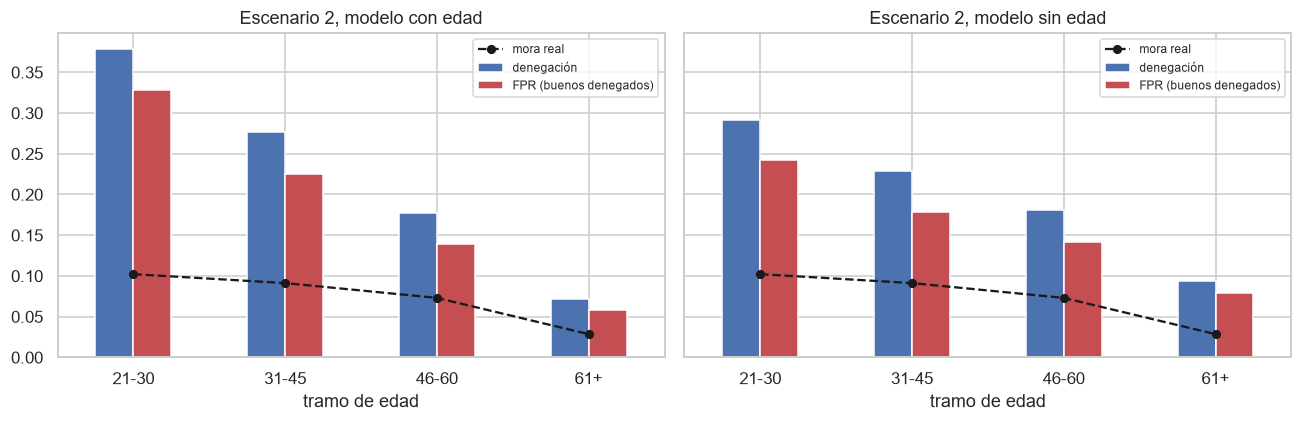

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (tabla, titulo) in zip(axes, [(equidad_con_edad, "con edad"), (equidad_sin_edad, "sin edad")]):
    tabla[["denegación", "FPR (buenos denegados)"]].plot(kind="bar", ax=ax, rot=0,
                                                          color=["#4C72B0", "#C44E52"])
    ax.plot(range(len(tabla)), tabla["mora_real"], "ko--", ms=5, label="mora real")
    ax.set_title(f"Escenario 2, modelo {titulo}")
    ax.set_xlabel("tramo de edad"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Lectura de equidad.** Bajo la política del escenario 2, un buen pagador de 21-30 años tiene
un **33% de probabilidad de ser denegado, frente al 6% de uno de 61+: disparidad de 5,7×** en la
tasa de falsos positivos. Parte es estadística legítima (los jóvenes presentan más impagos: 10,2% vs 2,9%),
pero el modelo va más allá de la base: usa la edad como atajo directo. Quitarla reduce la
disparidad de FPR a 3,1× (24% vs 8%) y solo encarece el coste de 0,335 a 0,338 (**+1%**), la
mitigación es baratísima en términos de la métrica oficial. Que no la elimine del todo delata
los *proxies* (los jóvenes tienen menos líneas, historiales más cortos, utilizaciones mayores).
El espejo de la moneda: el FNR se invierte (se "escapan" el 45% de los morosos mayores),
igualar FPR entre grupos sube el FNR de otros; **ninguna política iguala todas las métricas a
la vez** (imposibilidad de Chouldechova), así que la elección de qué disparidad tolerar es, de
nuevo, una decisión de negocio/regulatoria y no del algoritmo. Nuestra recomendación en §12.

### 9.6 Estabilidad de las explicaciones entre escenarios

In [155]:
# ¿Cambian las explicaciones si cambiamos de escenario?
# Ruta A (elegida): mismo modelo, distinto umbral → los SHAP son IDÉNTICOS por construcción;
#   lo que cambia es la frontera. Comprobamos qué parte del test cambia de decisión.
# Ruta B (descartada en §5): modelo reponderado spw=10 → ¿habrían cambiado las explicaciones?
from scipy.stats import spearmanr

cambian = (pred1_test != pred2_test).mean()
print(f"Casos de test cuya DECISIÓN cambia entre escenarios (mismo modelo): {cambian:.1%}")

modelo_spw = crea_lgbm(scale_pos_weight=10).fit(X_dev, y_dev)
sv_spw = shap.TreeExplainer(modelo_spw)(muestra_test)
imp_spw = pd.Series(np.abs(sv_spw.values).mean(0), index=muestra_test.columns)

rho = spearmanr(importancia.reindex(muestra_test.columns), imp_spw)[0]
comparacion = pd.DataFrame({"|SHAP| modelo neutro": importancia,
                            "|SHAP| modelo spw=10": imp_spw.reindex(importancia.index)}).round(3)
print(f"Correlación de Spearman entre rankings de importancia: {rho:.3f}")
comparacion

Casos de test cuya DECISIÓN cambia entre escenarios (mismo modelo): 17.3%
Correlación de Spearman entre rankings de importancia: 0.989


,|SHAP| modelo neutro,|SHAP| modelo spw=10
RevolvingUtilizationOfUnsecuredLines,0.712,0.706
NumberOfTime30-59DaysPastDueNotWorse,0.292,0.309
age,0.250,0.316
NumberOfOpenCreditLinesAndLoans,0.208,0.232
NumberOfTimes90DaysLate,0.205,0.213
MonthlyIncome,0.144,0.189
DebtRatio,0.143,0.184
NumberOfTime60-89DaysPastDueNotWorse,0.136,0.147
NumberRealEstateLoansOrLines,0.082,0.098
NumberOfDependents,0.043,0.061


### Interpretación de la sección 9

La sección 9 combina varias técnicas de explicabilidad para auditar el modelo desde ángulos complementarios. La conclusión central es consistente con el subrogado (§7) y con los contrafactuales (§8): **la utilización del crédito revolving y el historial de retrasos son los principales determinantes del riesgo estimado; la edad modula algunas decisiones; los ingresos tienen un papel menor y deben interpretarse con cautela**.

SHAP aporta la lectura global y local de las contribuciones: identifica qué variables empujan las predicciones hacia mayor o menor riesgo y permite explicar los seis clientes seleccionados en §8 con el mismo lenguaje que se usa para la auditoría global. La permutation importance por coste complementa esa lectura porque no mide solo cuánto cambia la probabilidad, sino cuánto empeora el coste de negocio cuando se elimina la información útil de una variable. Esto separa las variables que explican mucho score de las variables que realmente afectan a decisiones caras bajo la matriz del escenario 2.

Los gráficos PDP, ICE y ALE analizan la forma funcional aprendida por el modelo. Permiten comprobar si el efecto de variables como la utilización o los retrasos es monótono, si aparecen saltos relevantes cerca de ciertos rangos y si el comportamiento medio oculta heterogeneidad entre clientes. LIME añade una segunda explicación local para los mismos seis casos, basada en una aproximación lineal alrededor de cada cliente. Cuando LIME, SHAP y los contrafactuales coinciden, la explicación individual gana robustez; cuando divergen, la diferencia se interpreta como una señal de frontera, no como una verdad causal.

El cruce entre contrafactuales y SHAP distingue entre variables explicativas y variables accionables. SHAP puede asignar importancia a variables que ayudan a explicar la predicción, pero que no deben convertirse en recomendaciones al cliente, como la edad. Los contrafactuales, en cambio, obligan a formular cambios plausibles dentro de restricciones de negocio. Esta comparación evita transformar una explicación estadística en una recomendación operativa inadecuada.

El análisis de equidad por edad muestra que la política optimizada por coste no agota la evaluación del modelo. Eliminar la edad aumenta el coste aproximadamente un 1%, pero reduce la disparidad de FPR de 5,7× a 3,1×. Este resultado cuantifica el intercambio entre eficiencia y equidad y proporciona una base objetiva para una decisión de gobernanza.

Por último, la estabilidad entre escenarios confirma que el cambio principal procede de la política de decisión y no de una explicación distinta del riesgo. Con la arquitectura elegida, un mismo modelo y dos umbrales, los SHAP son idénticos por construcción; el 17,3% del test que cambia de decisión entre escenarios cambia porque se endurece el umbral. Incluso con la alternativa de reponderar el entrenamiento (`scale_pos_weight=10`), el ranking de importancias apenas se mueve (Spearman 0,989). Para gobernanza, esto implica que la matriz de coste cambia **a quién se deniega**, pero no altera de forma sustancial **por qué** el modelo considera arriesgado a un cliente.

## 10. Discusión: ¿y el enfoque multi-armed bandit?

El enunciado plantea el bandit contextual como alternativa al modelo supervisado. Lo
descartamos como solución principal por razones estructurales, y lo simulamos brevemente para
cuantificar el argumento.

**Por qué no encaja aquí**: 
* Un bandit está diseñado para aprender *online* pagando el
precio de la exploración, pero nuestro problema es un dataset estático con **todas las
etiquetas ya disponibles**, usar un bandit es autoimponerse ceguera: descubrir secuencialmente
lo que ya sabemos.
* En crédito real el feedback es **parcial y asimétrico**: si deniegas
nunca observas si el cliente habría pagado (*selective labels*), así que el brazo "denegar" no
genera aprendizaje, nuestra simulación, que revela la etiqueta siempre, es de hecho *generosa*
con el bandit.
* El fichero de producción no admite interacción: hay que decidir las 45.000
solicitudes de golpe, sin recibir recompensas intermedias.

El mapeo formal del bandit al problema de crédito sería:

| Elemento bandit | Adaptación al crédito |
|---|---|
| Contexto | Variables del cliente |
| Acción 0 | Conceder |
| Acción 1 | Denegar |
| Reward | `-coste` de la decisión |
| Regret | Coste extra frente a la política óptima supervisada |

Esta tabla muestra que no descartamos bandits "porque sí": el encaje formal
existe, pero el supuesto operativo que los hace útiles, aprender online observando recompensas tras
cada acción, no existe en el fichero de producción ni es observable para los créditos denegados.

Simulamos un **LinUCB** (bandit contextual lineal con bonus de exploración) sobre el stream de
desarrollo barajado, con las recompensas del escenario 2: conceder a un moroso cuesta 10,
denegar a un bueno cuesta 1.

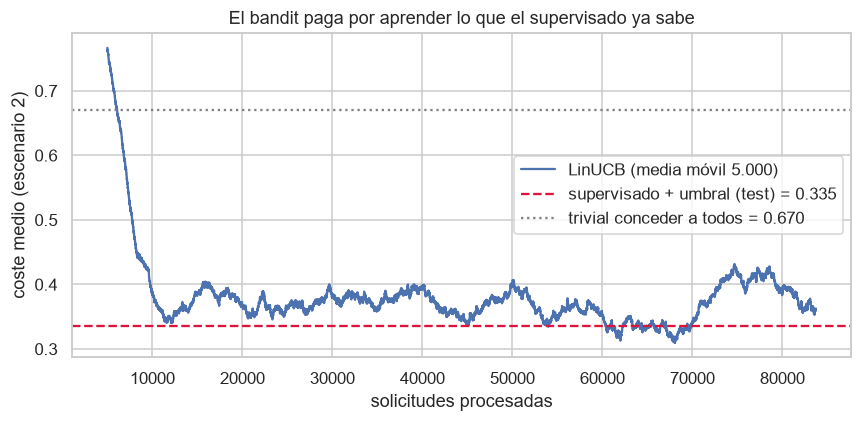

Coste medio del bandit — total del stream: 0.3951
  primeras 10.000 solicitudes: 0.5764
  últimas 20.000 solicitudes:  0.3801


In [156]:
# LinUCB contextual de dos brazos (0=conceder, 1=denegar) — escenario 2
rng_bandit = np.random.default_rng(SEED)

mediana_dev = X_dev.median()
X_imputado = X_dev.fillna(mediana_dev)
Z = ((X_imputado - X_imputado.mean()) / X_imputado.std()).to_numpy()
y_stream = y_dev.to_numpy()
orden_stream = rng_bandit.permutation(len(Z))

d_dim = Z.shape[1] + 1          # + intercepto
ALPHA = 1.0                     # intensidad de exploración
A = [np.eye(d_dim), np.eye(d_dim)]          # matrices de diseño por brazo
A_inv = [np.eye(d_dim), np.eye(d_dim)]
b = [np.zeros(d_dim), np.zeros(d_dim)]
costes_stream = np.empty(len(orden_stream))

for paso, i in enumerate(orden_stream):
    x = np.concatenate([[1.0], Z[i]])
    ucb = [A_inv[a] @ b[a] @ x + ALPHA * np.sqrt(x @ A_inv[a] @ x) for a in (0, 1)]
    accion = int(np.argmax(ucb))
    coste = 10.0 * y_stream[i] if accion == 0 else 1.0 * (1 - y_stream[i])
    A[accion] += np.outer(x, x)
    b[accion] += -coste * x                  # recompensa = -coste
    A_inv[accion] = np.linalg.inv(A[accion])
    costes_stream[paso] = coste

ventana = 5000
media_movil = np.convolve(costes_stream, np.ones(ventana) / ventana, mode="valid")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(len(media_movil)) + ventana, media_movil, label="LinUCB (media móvil 5.000)")
ax.axhline(coste2_test, color="crimson", ls="--", label=f"supervisado + umbral (test) = {coste2_test:.3f}")
ax.axhline(10 * y_dev.mean(), color="gray", ls=":", label=f"trivial conceder a todos = {10*y_dev.mean():.3f}")
ax.set_xlabel("solicitudes procesadas"); ax.set_ylabel("coste medio (escenario 2)")
ax.set_title("El bandit paga por aprender lo que el supervisado ya sabe")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Coste medio del bandit — total del stream: {costes_stream.mean():.4f}")
print(f"  primeras 10.000 solicitudes: {costes_stream[:10000].mean():.4f}")
print(f"  últimas 20.000 solicitudes:  {costes_stream[-20000:].mean():.4f}")

### Interpretación de la sección 10

Los números cierran la discusión: el LinUCB paga **0,58 de coste medio durante sus primeras
10.000 solicitudes** (86.000 unidades de coste de "matrícula") y se estabiliza en ~0,38, todavía
un **13% por encima** del supervisado con umbral (0,335), un modelo lineal por brazo no captura
las no-linealidades que LightGBM sí (la misma brecha que la logística en §4, agravada por
aprender de a una observación). Y esto en la simulación *idealizada* donde el bandit observa la
etiqueta aunque deniegue; con feedback selectivo real, el brazo "denegar" sería un agujero negro
informativo. **El bandit es la herramienta correcta para otro problema**: cuando no existe
histórico etiquetado (producto nuevo, mercado nuevo) o cuando la política actual censura los
datos y hace falta exploración deliberada para des-sesgar. Con 105.000 etiquetas en la mano,
elegirlo aquí sería un error de casting.

## 11. Generación de `cs_produccion1.csv` y `cs_produccion2.csv`

Pipeline final, replicando en grande el procedimiento validado en §4-§5:

1. OOF de 5 folds sobre **toda** la construcción limpia (104.668 filas) → umbral óptimo de
   cada escenario (más datos → umbral más estable que el de desarrollo).
2. Reentrenamiento del modelo final con toda la construcción.
3. Predicción de las 45.000 filas de producción y escritura de los CSV **replicando el formato
   original** (mismas columnas y orden de filas; solo se rellena `SeriousDlqin2yrs`).

In [157]:
# 1) Umbrales finales sobre OOF de construcción completa
oof_final = cross_val_predict(crea_lgbm(), X_full, y_full, cv=cv, method="predict_proba")[:, 1]
t1_final, c1_oof_final = umbral_optimo(y_full, oof_final, C_FP_1, C_FN_1)
t2_final, c2_oof_final = umbral_optimo(y_full, oof_final, C_FP_2, C_FN_2)
print(f"Escenario 1: umbral final {t1_final:.4f} (coste OOF {c1_oof_final:.4f})")
print(f"Escenario 2: umbral final {t2_final:.4f} (coste OOF {c2_oof_final:.4f})")

# 2) Modelo final y 3) predicciones de producción
modelo_final = crea_lgbm().fit(X_full, y_full)
proba_prod = modelo_final.predict_proba(X_prod)[:, 1]
pred_prod_1 = (proba_prod > t1_final).astype(int)
pred_prod_2 = (proba_prod > t2_final).astype(int)

print(f"\nDenegaciones en producción — E1: {pred_prod_1.sum():,} ({pred_prod_1.mean():.2%}) "
      f"| E2: {pred_prod_2.sum():,} ({pred_prod_2.mean():.2%})")
print(f"Denegaciones en test (referencia) — E1: {pred1_test.mean():.2%} | E2: {pred2_test.mean():.2%}")

Escenario 1: umbral final 0.5231 (coste OOF 0.0628)
Escenario 2: umbral final 0.0916 (coste OOF 0.3320)

Denegaciones en producción — E1: 905 (2.01%) | E2: 8,137 (18.08%)
Denegaciones en test (referencia) — E1: 1.50% | E2: 18.83%


In [158]:
# Escritura replicando el formato del fichero original (solo cambia el target)
salida1 = df_pro.copy()
salida1[TARGET] = pred_prod_1
salida1.to_csv("cs_produccion1.csv", index=False)

salida2 = df_pro.copy()
salida2[TARGET] = pred_prod_2
salida2.to_csv("cs_produccion2.csv", index=False)

# Verificación de integridad de los entregables
for fichero, pred in [("cs_produccion1.csv", pred_prod_1), ("cs_produccion2.csv", pred_prod_2)]:
    releido = pd.read_csv(fichero)
    assert releido.shape == df_pro.shape, "dimensiones alteradas"
    assert list(releido.columns) == list(df_pro.columns), "columnas alteradas"
    assert releido[TARGET].isna().sum() == 0, "predicciones incompletas"
    assert releido[TARGET].isin([0, 1]).all(), "valores fuera de {0,1}"
    assert (releido[TARGET].values == pred).all(), "predicciones no coinciden"
    assert releido.drop(columns=TARGET).equals(df_pro.drop(columns=TARGET)), "features alteradas"
    print(f"{fichero}: OK — {len(releido):,} filas, {releido[TARGET].sum():,} denegaciones")

salida2.head(3)

cs_produccion1.csv: OK — 45,000 filas, 905 denegaciones
cs_produccion2.csv: OK — 45,000 filas, 8,137 denegaciones


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1.000000,30,0,0.18512,1706.0,0,4,0,0,3.0
1,1,1.000000,46,0,0.00000,0.0,0,2,0,0,3.0
2,0,0.040356,37,0,1831.00000,NaN,5,0,1,0,0.0


### Interpretación de la sección 11

Los dos entregables quedan escritos y verificados (45.000 filas intactas, mismas columnas,
predicción binaria completa). Las tasas de denegación de producción (2,0% y 18,1%) calcan las
de test (1,5% y 18,8%), la pequeña diferencia del escenario 1 viene de la zona plana del
umbral (§4), donde mover el corte de 0,58 a 0,52 apenas cambia el coste pero sí el recuento de
una población minúscula. Dado el no-drift verificado en §2.7, nuestra estimación del coste
que estos ficheros obtendrán al corregirse es la de test: **≈0,064 (escenario 1) y ≈0,335
(escenario 2)** por solicitud.

## 12. Reflexión final crítica

In [159]:
# Tabla resumen final (generada desde las variables, no copiada a mano)
tabla_final = pd.DataFrame({
    "Escenario 1 (FP=1, FN=1)": {
        "modelo": "LightGBM compacto (300x15)",
        "umbral producción": round(t1_final, 4),
        "coste OOF construcción": round(c1_oof_final, 4),
        "coste test (estimación producción)": round(coste1_test, 4),
        "trivial a batir": round(float(y_test.mean()), 4),
        "denegaciones producción": f"{pred_prod_1.sum():,} ({pred_prod_1.mean():.1%})"},
    "Escenario 2 (FP=1, FN=10)": {
        "modelo": "el mismo (otro umbral)",
        "umbral producción": round(t2_final, 4),
        "coste OOF construcción": round(c2_oof_final, 4),
        "coste test (estimación producción)": round(coste2_test, 4),
        "trivial a batir": round(float(10 * y_test.mean()), 4),
        "denegaciones producción": f"{pred_prod_2.sum():,} ({pred_prod_2.mean():.1%})"},
})
tabla_final

,"Escenario 1 (FP=1, FN=1)","Escenario 2 (FP=1, FN=10)"
modelo,LightGBM compacto (300x15),el mismo (otro umbral)
umbral producción,0.5231,0.0916
coste OOF construcción,0.0628,0.332
coste test (estimación producción),0.0635,0.3351
trivial a batir,0.067,0.6702
denegaciones producción,905 (2.0%),"8,137 (18.1%)"


### Conclusiones

Un único LightGBM calibrado más dos umbrales resuelve ambos escenarios: **0,0635** de coste
frente al trivial 0,0668 en el escenario simétrico (mejora modesta e inherente al problema) y
**0,3351** frente a 0,668 en el asimétrico (el modelo vale la mitad del coste). La metodología
OOF→test evitó el autoengaño del umbral sobreajustado (OOF y test coinciden a 3 decimales), y
la auditoría triple (subrogado 91% fiel, contrafactuales, SHAP) converge en la misma anatomía:
utilización de crédito e historial de retrasos deciden, la edad modula.

### Limitaciones que hay que confesar

1. **Etiquetas selectivas**: la construcción contiene solo créditos *concedidos* por la
   política histórica del banco. Los perfiles que aquella política rechazó no existen en los
   datos, y nuestro modelo hereda esa ceguera (*reject inference* sin resolver). El coste medido
   es fiel para poblaciones como la de producción que, es idéntica (§2.7), pero
   no autoriza a extender el sistema a segmentos nuevos.
2. **La matriz de coste es una caricatura**: FP=1/FN=10 uniformes ignoran el importe de cada
   préstamo, la pérdida real en caso de impago (LGD) y el margen por cliente. Con importes, el
   umbral debería ser por-solicitud (denegar si p·importe·LGD > margen), no global.
3. **No-monotonías aprendidas**: el modelo cree que ganar menos o abrir más líneas puede
   reducir el riesgo (§8, §9). Estadística legítima, causalidad absurda, y una puerta abierta
   al *gaming* si las explicaciones se publican.
4. **La edad discrimina**: FPR de 33% en jóvenes vs 6% en mayores bajo la política estricta.
   Medimos que mitigarlo cuesta +1% de coste; no lo aplicamos a los entregables porque la
   métrica de evaluación de la práctica es el coste puro, pero en un despliegue real esa
   decisión debería tomarla un comité con la tabla de §9.3 delante , y dejamos constancia de
   que nosotros la pondríamos sobre la mesa.
5. **Snapshot temporal único**: sin fechas, no hay validación temporal posible. Un modelo de
   crédito entrenado en un punto del ciclo económico y evaluado en el mismo punto sobreestima
   su vida útil; el primer cambio de ciclo lo descalibrará.

### Riesgos de despliegue

El umbral 0,092 es óptimo *para esta tasa base*: si la tasa poblacional de impago sube (recesión), el
umbral óptimo se mueve y el coste real diverge del estimado , hace falta **monitorización de
calibración y de drift** con recalibración periódica, no reentrenos ciegos. Publicar
explicaciones crea **incentivos de manipulación** (bajar la utilización un mes antes de
solicitar); las variables de historial son más robustas al gaming que las de saldo. Y el
sistema entra de lleno en la categoría de **alto riesgo del EU AI Act**: registro, supervisión
humana, derecho a explicación, nuestra banda gris propuesta (p ∈ [0,06, 0,12] a revisión
humana, §8) atacaría a la vez la inestabilidad de frontera y el requisito regulatorio.

### Con más tiempo y datos

Por orden de retorno esperado:
* **Restricciones monótonas** en LightGBM para ingresos, utilización y retrasos, elimina las no-monotonías espurias y el gaming barato casi gratis.
* **Coste por importe** del préstamo si existiera esa columna, es la mejora de negocio más grande disponible. 
* **Calibración isotónica** + re-derivación analítica del umbral, que haría el sistema robusto a renegociaciones de la matriz. 
* **Reject inference** (p. ej. aprendizaje semi-supervisado sobre los denegados históricos) antes de tocar segmentos nuevos.
* Información crediticia externos y variables de tendencia (¿la utilización sube o baja?), que
probablemente valen más que cualquier sofisticación algorítmica sobre las 10 columnas actuales.